# Semi-Supervised ERP Training (5-Fold CV)

This notebook trains multiple CNN models on real ERP images with label-driven augmentation:

1. Load the merged 500 manual labels (same merge logic as `model_validate.ipynb`).
2. Build ERP images with the standard preprocessing pipeline.
3. Apply modulo-4 split augmentation to all ERP images: keep **one** split for `no class` and keep **all four** splits for class-labelled ERP images (`erp_class > 0`).
4. Train and validate the following models with **5-fold group cross-validation**:
   - `cnn_1conv`
   - `cnn_3conv`
   - `cnn_10conv` (ResNet-style, 10 conv layers)
   - `resnet18_pretrained` (ImageNet pre-trained backbone via Metalhead)
5. Print fold-level and aggregated tables for:
   - performance metrics
   - training/validation timing per model

Reference docs used for ResNet/Metalhead:
- https://fluxml.ai/Metalhead.jl/dev/howto/resnet/
- https://fluxml.ai/Metalhead.jl/dev/howto/pretrained/


In [1]:
versioninfo()


Julia Version 1.12.3
Commit 966d0af0fdf (2025-12-15 11:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 16 × AMD Ryzen 7 7800X3D 8-Core Processor
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, znver4)
  GC: Built with stock GC
Threads: 16 default, 1 interactive, 16 GC (on 16 virtual cores)
Environment:
  JULIA_NUM_THREADS = 16


In [2]:
import Pkg

# Keep notebook startup stable.
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

Pkg.activate(".")

using CSV, DataFrames, HDF5, Statistics, Random, Printf, Dates
using CairoMakie
using Flux
using Flux: onehotbatch, onecold
using CUDA
using cuDNN
using MLUtils: DataLoader
using StatisticalMeasures
using StatisticalMeasures: macro_avg
using PrettyTables
using Metalhead
using ImageFiltering: imfilter, imgradients, KernelFactors, Kernel, mapwindow
using Images: imresize, dilate, erode, opening, closing, tophat, bothat, morphogradient, morpholaplace
using ImageContrastAdjustment: adjust_histogram, AdaptiveEqualization, Equalization, ContrastStretching

include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
using .ERPImageUtils: gaussian_kernel, zscore_timepoints

# GPU requirement: use NVIDIA RTX 4070.
@assert CUDA.functional(true) "CUDA is not functional. GPU training cannot run."
CUDA.allowscalar(false)
CUDA.device!(0)

gpu_name = CUDA.name(CUDA.device())
println("CUDA device: ", gpu_name)
@assert occursin("4070", gpu_name) "Expected RTX 4070, got: $(gpu_name)"

device(x) = cu(x)

const SAMPLING_RATE = 512
const PRE_STIM_S = 0.5
const TIME_ZERO_IDX = Int(round(PRE_STIM_S * SAMPLING_RATE)) + 1
const TARGET_SIZE = (64, 64)
const LOWPASS_SIGMA = 75.0f0
const LOWPASS_KERNEL_SIZE = (21, 21)
const FILTER_BORDER = "reflect"

"""
    tv_denoise(img, λ; num_iters=50)

Simple Total Variation denoising via gradient descent (ROF model).
Minimizes: ‖u - img‖² + λ·TV(u), where TV is the isotropic total variation.
"""
function tv_denoise(img::AbstractMatrix{Float32}, λ::Float32; num_iters::Int=50)
    u = copy(img)
    h, w = size(u)
    τ = 0.125f0  # step size (must be < 1/4 for stability)
    for _ in 1:num_iters
        # Compute divergence of normalized gradient
        div = zeros(Float32, h, w)
        for i in 1:h, j in 1:w
            # Forward differences with Neumann boundary
            dx = (i < h ? u[i+1, j] - u[i, j] : 0f0)
            dy = (j < w ? u[i, j+1] - u[i, j] : 0f0)
            grad_norm = sqrt(dx^2 + dy^2 + 1f-8)
            nx = dx / grad_norm
            ny = dy / grad_norm
            # Divergence via backward differences
            div_x = nx - (i > 1 ? (let dx2 = (u[i, j] - u[i-1, j]),
                                        dy2 = (j < w ? u[i-1, j+1] - u[i-1, j] : 0f0),
                                        gn2 = sqrt(dx2^2 + dy2^2 + 1f-8)
                                    dx2 / gn2 end) : 0f0)
            div_y = ny - (j > 1 ? (let dx2 = (i < h ? u[i+1, j-1] - u[i, j-1] : 0f0),
                                        dy2 = (u[i, j] - u[i, j-1]),
                                        gn2 = sqrt(dx2^2 + dy2^2 + 1f-8)
                                    dy2 / gn2 end) : 0f0)
            div[i, j] = div_x + div_y
        end
        @. u = u + τ * (λ * div - (u - img))
    end
    return u
end

const RESULTS_CSV_PATHS = [
    joinpath(pwd(), "results", "project-14-at-2026-02-15-23-09-f5225e5c.csv"),
    joinpath(pwd(), "results", "project-15-at-2026-02-18-19-35-828515fe.csv"),
]
const H5_PATH = joinpath(pwd(), "data_fixations.hdf5")
const EVENTS_CSV_PATH = joinpath(pwd(), "events.csv")

for p in vcat(RESULTS_CSV_PATHS, [H5_PATH, EVENTS_CSV_PATH])
    @assert isfile(p) "File not found: $p"
end


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


CUDA device: NVIDIA GeForce RTX 4070


In [3]:
function load_erps_from_h5(path::AbstractString)
    return h5open(path, "r") do f
        candidates = ["erps", "/erps", "data", "/data/data_fixations.hdf5", "data/data_fixations.hdf5"]
        for key in candidates
            if haskey(f, key)
                obj = f[key]
                if obj isa HDF5.Dataset
                    return read(obj)
                end
            end
        end

        function first_dataset(g)
            for k in keys(g)
                obj = g[k]
                if obj isa HDF5.Dataset
                    return read(obj)
                elseif obj isa HDF5.Group
                    x = first_dataset(obj)
                    x === nothing || return x
                end
            end
            return nothing
        end

        x = first_dataset(f)
        x === nothing && error("No dataset found in HDF5 file: $path")
        return x
    end
end

function load_and_merge_label_sources(paths::Vector{String})
    dfs = DataFrame[]
    for p in paths
        df = CSV.read(p, DataFrame)
        df.source_csv = fill(basename(p), nrow(df))
        push!(dfs, df)
    end

    labels_all = vcat(dfs...; cols = :union)

    if :image in names(labels_all)
        updated_at_str = :updated_at in names(labels_all) ? string.(coalesce.(labels_all.updated_at, "")) : fill("", nrow(labels_all))
        created_at_str = :created_at in names(labels_all) ? string.(coalesce.(labels_all.created_at, "")) : fill("", nrow(labels_all))
        labels_all.updated_at_str = updated_at_str
        labels_all.created_at_str = created_at_str

        sort!(labels_all, [:image, :updated_at_str, :created_at_str], rev = [false, true, true])
        labels_merged = unique(labels_all, :image)
    else
        labels_merged = labels_all
    end

    return labels_all, labels_merged
end

parse_class_id(v) = begin
    t = tryparse(Int, strip(string(v)))
    t === nothing ? missing : t
end

function has_required_metadata(row)
    cols = propertynames(row)
    if !(:channel in cols && :sort_variable in cols)
        return false
    end
    return !ismissing(row.channel) && !ismissing(row.sort_variable)
end

erps = load_erps_from_h5(H5_PATH)
events = CSV.read(EVENTS_CSV_PATH, DataFrame)
labels_all_df, labels_merged_df = load_and_merge_label_sources(RESULTS_CSV_PATHS)

labels_merged_df.erp_class_id = [parse_class_id(v) for v in labels_merged_df.erp_class]
valid_mask = map(v -> !ismissing(v), labels_merged_df.erp_class_id)
meta_mask = map(has_required_metadata, eachrow(labels_merged_df))
labels_df = copy(labels_merged_df[valid_mask .& meta_mask, :])

labels_df.channel_int = Int.(labels_df.channel)
labels_df.sort_var_symbol = Symbol.(String.(labels_df.sort_variable))
labels_df.binary_label = Int.(labels_df.erp_class_id .> 0)

println("ERP tensor size: ", size(erps), " (channel, time, trial)")
println("Events rows: ", nrow(events))
println("Labels imported (all): ", nrow(labels_all_df))
println("Labels merged unique by image: ", nrow(labels_merged_df))
println("Labels used for training: ", nrow(labels_df))

println("Class distribution (binary):")
show(combine(groupby(labels_df, :binary_label), nrow => :count), allrows = true, allcols = true)
println()


ERP tensor size: (128, 769, 2508) (channel, time, trial)
Events rows: 2508
Labels imported (all): 500
Labels merged unique by image: 500
Labels used for training: 500
Class distribution (binary):
2×2 DataFrame
 Row │ binary_label  count 
     │ Int64         Int64 
─────┼─────────────────────
   1 │            0    452
   2 │            1     48


In [4]:
function sortvalues_from(df::DataFrame, col::Symbol)
    v = df[!, col]
    if eltype(v) <: Number
        return Float64.(v)
    end
    return collect(v)
end

function extract_channel_trials(erps, events::DataFrame, channel::Int; time_zero_idx::Int = TIME_ZERO_IDX)
    @assert 1 <= channel <= size(erps, 1) "channel out of range"
    data = Float32.(erps[channel, time_zero_idx:end, :])
    n = min(size(data, 2), nrow(events))
    return data[:, 1:n], events[1:n, :]
end

function preprocess_erp_subset(data_time_trials::AbstractMatrix, events_trials::DataFrame, sort_col::Symbol;
    target_size::Tuple{Int, Int} = TARGET_SIZE,
    low_pass_sigma::Float32 = LOWPASS_SIGMA,
    lowpass_kernel_size::Tuple{Int, Int} = LOWPASS_KERNEL_SIZE,
    filter_border::String = FILTER_BORDER)

    @assert size(data_time_trials, 2) == nrow(events_trials) "trial count mismatch between matrix and events"
    @assert sort_col in propertynames(events_trials) "sort column not found: $(sort_col)"

    sortvals = sortvalues_from(events_trials, sort_col)
    order = sortperm(sortvals)
    data_sorted = data_time_trials[:, order]

    data_z = zscore_timepoints(data_sorted)
    img_trials_time = Float32.(permutedims(data_z, (2, 1)))

    kernel = gaussian_kernel(low_pass_sigma, size(img_trials_time), target_size, lowpass_kernel_size)
    img_lowpass = Float32.(imfilter(img_trials_time, kernel, filter_border))

    return Float32.(imresize(img_lowpass, target_size))
end

function split_indices_sorted_modulo(events_trials::DataFrame, sort_col::Symbol, k::Int)
    n = nrow(events_trials)
    n == 0 && return [Int[]]
    k_eff = min(max(k, 1), n)

    sortvals = sortvalues_from(events_trials, sort_col)
    order = sortperm(sortvals)

    groups = [Int[] for _ in 1:k_eff]
    for (i, idx) in enumerate(order)
        push!(groups[((i - 1) % k_eff) + 1], idx)
    end

    return groups
end

function image_id_from_row(row)
    cols = propertynames(row)
    if :image_file in cols && !ismissing(row.image_file)
        return String(row.image_file)
    end
    if :image in cols && !ismissing(row.image)
        return String(row.image)
    end
    return "unknown_image"
end

function build_training_dataset(erps, events::DataFrame, labels_df::DataFrame;
    positive_split_k::Int = 4,
    no_class_split_k::Int = 4,
    no_class_pick_rng::AbstractRNG = Random.GLOBAL_RNG,
    target_size::Tuple{Int, Int} = TARGET_SIZE)

    rows = NamedTuple[]
    imgs = Matrix{Float32}[]

    for (row_uid, row) in enumerate(eachrow(labels_df))
        channel = Int(row.channel_int)
        sort_col = row.sort_var_symbol
        class_id = Int(row.erp_class_id)
        binary = Int(class_id > 0)
        image_id = image_id_from_row(row)

        data_full, events_full = extract_channel_trials(erps, events, channel)

        if binary == 0
            # For no-class rows, split modulo-4 and keep exactly one random split.
            groups = split_indices_sorted_modulo(events_full, sort_col, no_class_split_k)
            keep_part = rand(no_class_pick_rng, eachindex(groups))
            idxs = groups[keep_part]

            data_part = data_full[:, idxs]
            events_part = events_full[idxs, :]
            img_part = preprocess_erp_subset(data_part, events_part, sort_col; target_size = target_size)

            push!(rows, (
                sample_id = length(rows) + 1,
                group_id = row_uid,
                image_id = image_id,
                channel = channel,
                sort_var = String(sort_col),
                class_id = class_id,
                binary_label = binary,
                variant = "mod4_keep$(keep_part)",
                n_trials = length(idxs),
            ))
            push!(imgs, img_part)
        else
            # Replace class-labelled samples with modulo splits only (no full image).
            groups = split_indices_sorted_modulo(events_full, sort_col, positive_split_k)
            for (part, idxs) in enumerate(groups)
                data_part = data_full[:, idxs]
                events_part = events_full[idxs, :]
                img_part = preprocess_erp_subset(data_part, events_part, sort_col; target_size = target_size)

                push!(rows, (
                    sample_id = length(rows) + 1,
                    group_id = row_uid,
                    image_id = image_id,
                    channel = channel,
                    sort_var = String(sort_col),
                    class_id = class_id,
                    binary_label = binary,
                    variant = "mod4_part$(part)",
                    n_trials = length(idxs),
                ))
                push!(imgs, img_part)
            end
        end
    end

    out_df = DataFrame(rows)
    out_df.processed_img = imgs
    return out_df
end

no_class_pick_seed = rand(UInt64)
no_class_pick_rng = MersenneTwister(no_class_pick_seed)

train_df = build_training_dataset(
    erps,
    events,
    labels_df;
    positive_split_k = 4,
    no_class_split_k = 4,
    no_class_pick_rng = no_class_pick_rng,
)

# Randomize sample order before training and validation.
shuffle_seed = rand(UInt64)
shuffle_rng = MersenneTwister(shuffle_seed)
perm = randperm(shuffle_rng, nrow(train_df))
train_df = train_df[perm, :]
train_df.sample_id = collect(1:nrow(train_df))

# Validate requested policy:
# - no-class: keep one modulo split only
# - class: keep all four modulo splits
@assert nrow(train_df[train_df.variant .== "full", :]) == 0
@assert nrow(train_df[(train_df.binary_label .== 0) .& .!startswith.(train_df.variant, "mod4_keep"), :]) == 0
@assert nrow(train_df[(train_df.binary_label .== 1) .& .!startswith.(train_df.variant, "mod4_part"), :]) == 0

println("\nTraining rows after augmentation: ", nrow(train_df))
println("Original rows: ", nrow(labels_df))
println("No-class split pick seed: ", no_class_pick_seed)
println("Shuffle seed: ", shuffle_seed)

input_stats_df = DataFrame(
    metric = [
        "original_labels",
        "augmented_samples_total",
        "unique_source_groups",
        "no_class_samples",
        "class_samples",
    ],
    value = [
        nrow(labels_df),
        nrow(train_df),
        length(unique(train_df.group_id)),
        count(==(0), train_df.binary_label),
        count(==(1), train_df.binary_label),
    ],
)

variant_stats_df = combine(
    groupby(train_df, [:binary_label, :variant]),
    nrow => :count,
    :n_trials => mean => :mean_trials,
    :n_trials => minimum => :min_trials,
    :n_trials => maximum => :max_trials,
)
sort!(variant_stats_df, [:binary_label, :variant])

println("\nInput data summary:")
pretty_table(input_stats_df)

println("\nInput data distribution by label/variant:")
pretty_table(variant_stats_df)



Training rows after augmentation: 644
Original rows: 500
No-class split pick seed: 7491703865932483616
Shuffle seed: 1500446146142511228

Input data summary:
┌─────────────────────────┬───────┐
│                  metric │ value │
│                  String │ Int64 │
├─────────────────────────┼───────┤
│         original_labels │   500 │
│ augmented_samples_total │   644 │
│    unique_source_groups │   500 │
│        no_class_samples │   452 │
│           class_samples │   192 │
└─────────────────────────┴───────┘

Input data distribution by label/variant:
┌──────────────┬────────────┬───────┬─────────────┬────────────┬────────────┐
│ binary_label │    variant │ count │ mean_trials │ min_trials │ max_trials │
│        Int64 │     String │ Int64 │     Float64 │      Int64 │      Int64 │
├──────────────┼────────────┼───────┼─────────────┼────────────┼────────────┤
│            0 │ mod4_keep1 │    88 │       627.0 │        627 │        627 │
│            0 │ mod4_keep2 │   119 │       627.

In [5]:
function images_to_tensor(imgs)
    h, w = size(imgs[1])
    n = length(imgs)
    x = Array{Float32}(undef, h, w, 1, n)
    for (i, img) in enumerate(imgs)
        x[:, :, 1, i] = Float32.(img)
    end
    return x
end

X_gray = images_to_tensor(train_df.processed_img)
X_rgb = repeat(X_gray, 1, 1, 3, 1)
y_binary = Int.(train_df.binary_label)
group_ids = Int.(train_df.group_id)

println("X_gray size: ", size(X_gray))
println("X_rgb size : ", size(X_rgb))
println("labels size: ", length(y_binary))
println("groups size: ", length(group_ids))

@assert size(X_gray, 4) == length(y_binary) == length(group_ids)


X_gray size: (64, 64, 1, 644)
X_rgb size : (64, 64, 3, 644)
labels size: 644
groups size: 644


In [6]:
function make_group_kfolds(group_ids::Vector{Int}, y_binary::Vector{Int}, sort_vars::Vector{String}, k::Int; seed::Int = 20260220)
    @assert length(group_ids) == length(y_binary) == length(sort_vars)

    n = length(group_ids)

    # Collect group metadata and verify consistency per group.
    group_to_indices = Dict{Int, Vector{Int}}()
    group_to_label = Dict{Int, Int}()
    group_to_sort = Dict{Int, String}()
    idx_to_group = Dict{Int, Int}()

    for (idx, gid) in enumerate(group_ids)
        lbl = y_binary[idx]
        sv = sort_vars[idx]

        if haskey(group_to_label, gid)
            @assert group_to_label[gid] == lbl "Group label mismatch for group $(gid)"
            @assert group_to_sort[gid] == sv "Group sort-variable mismatch for group $(gid)"
        else
            group_to_label[gid] = lbl
            group_to_sort[gid] = sv
            group_to_indices[gid] = Int[]
        end

        push!(group_to_indices[gid], idx)
        idx_to_group[idx] = gid
    end

    # Positive groups with multiple samples are augmented groups (typically 4 variants).
    # New requirement: distribute these samples across folds instead of keeping them together.
    split_positive_groups = Set{Int}()
    for gid in keys(group_to_indices)
        if group_to_label[gid] == 1 && length(group_to_indices[gid]) > 1
            push!(split_positive_groups, gid)
        end
    end

    # All other groups stay fold-locked as before.
    locked_groups = [gid for gid in keys(group_to_indices) if !(gid in split_positive_groups)]

    rng = MersenneTwister(seed)

    fold_val_indices = [Int[] for _ in 1:k]
    fold_pos_counts = zeros(Int, k)
    fold_sort_counts = [Dict{String, Int}() for _ in 1:k]
    idx_to_fold = zeros(Int, n)

    function add_index_to_fold!(fold::Int, idx::Int)
        push!(fold_val_indices[fold], idx)

        lbl = y_binary[idx]
        sv = sort_vars[idx]
        if lbl == 1
            fold_pos_counts[fold] += 1
        end
        fold_sort_counts[fold][sv] = get(fold_sort_counts[fold], sv, 0) + 1

        idx_to_fold[idx] = fold
    end

    function remove_index_from_fold!(fold::Int, idx::Int)
        pos = findfirst(==(idx), fold_val_indices[fold])
        pos === nothing && return false
        deleteat!(fold_val_indices[fold], pos)

        lbl = y_binary[idx]
        sv = sort_vars[idx]
        if lbl == 1
            fold_pos_counts[fold] -= 1
        end

        fold_sort_counts[fold][sv] = get(fold_sort_counts[fold], sv, 0) - 1
        if fold_sort_counts[fold][sv] <= 0
            delete!(fold_sort_counts[fold], sv)
        end

        idx_to_fold[idx] = 0
        return true
    end

    function add_group_to_fold!(fold::Int, gid::Int)
        for idx in group_to_indices[gid]
            add_index_to_fold!(fold, idx)
        end
    end

    # Phase 1: assign locked groups with stratified round-robin by (label, sort_var).
    stratum_to_locked_groups = Dict{Tuple{Int, String}, Vector{Int}}()
    for gid in locked_groups
        stratum = (group_to_label[gid], group_to_sort[gid])
        if !haskey(stratum_to_locked_groups, stratum)
            stratum_to_locked_groups[stratum] = Int[]
        end
        push!(stratum_to_locked_groups[stratum], gid)
    end

    for stratum in sort!(collect(keys(stratum_to_locked_groups)); by = x -> (x[1], x[2]))
        gids = shuffle(rng, stratum_to_locked_groups[stratum])
        for (i, gid) in enumerate(gids)
            fold = ((i - 1) % k) + 1
            add_group_to_fold!(fold, gid)
        end
    end

    # Phase 2: split each augmented positive group across folds.
    # Also stratify by sort-variable and bias assignment to folds with fewer positives.
    sort_to_split_groups = Dict{String, Vector{Int}}()
    for gid in split_positive_groups
        sv = group_to_sort[gid]
        if !haskey(sort_to_split_groups, sv)
            sort_to_split_groups[sv] = Int[]
        end
        push!(sort_to_split_groups[sv], gid)
    end

    for sv in sort!(collect(keys(sort_to_split_groups)))
        gids = shuffle(rng, sort_to_split_groups[sv])

        for gid in gids
            idxs = shuffle(rng, copy(group_to_indices[gid]))
            used_folds = Set{Int}()

            for idx in idxs
                candidates = [f for f in 1:k if !(f in used_folds)]
                isempty(candidates) && (candidates = collect(1:k))

                best_fold = candidates[1]
                best_key = (typemax(Int), typemax(Int), typemax(Int), typemax(Int))

                for f in candidates
                    key = (
                        fold_pos_counts[f],
                        get(fold_sort_counts[f], sv, 0),
                        length(fold_val_indices[f]),
                        f,
                    )
                    if key < best_key
                        best_key = key
                        best_fold = f
                    end
                end

                add_index_to_fold!(best_fold, idx)
                push!(used_folds, best_fold)
            end
        end
    end

    # Optional correction: reduce positive-count gap while keeping split-group spread.
    max_iters = 5000
    iter = 0
    while iter < max_iters
        iter += 1

        src = argmax(fold_pos_counts)
        dst = argmin(fold_pos_counts)
        gap = fold_pos_counts[src] - fold_pos_counts[dst]
        gap <= 1 && break

        best_idx = nothing
        best_key = (typemax(Int), typemax(Int), typemax(Int))

        for idx in fold_val_indices[src]
            y_binary[idx] == 1 || continue
            gid = idx_to_group[idx]

            if gid in split_positive_groups
                # Keep each augmented sample of one source group on distinct folds.
                dst_has_same_gid = any(idx_to_fold[j] == dst for j in group_to_indices[gid] if j != idx)
                dst_has_same_gid && continue
            else
                # Preserve lock for non-split multi-sample groups.
                if length(group_to_indices[gid]) > 1
                    continue
                end
            end

            sv = sort_vars[idx]
            key = (
                get(fold_sort_counts[dst], sv, 0),
                get(fold_sort_counts[src], sv, 0),
                idx,
            )

            if key < best_key
                best_key = key
                best_idx = idx
            end
        end

        best_idx === nothing && break

        moved = remove_index_from_fold!(src, best_idx)
        moved || break
        add_index_to_fold!(dst, best_idx)
    end

    # Validate augmented split constraint.
    for gid in split_positive_groups
        folds = unique(idx_to_fold[idx] for idx in group_to_indices[gid])
        expected = min(k, length(group_to_indices[gid]))
        @assert length(folds) == expected "Split constraint violated for positive group $(gid): got $(length(folds)) distinct folds, expected $(expected)."
    end

    for fold in 1:k
        sort!(fold_val_indices[fold])
    end

    return fold_val_indices
end

function compute_metrics(y_pred::Vector{Int}, y_true::Vector{Int})

    acc = StatisticalMeasures.Accuracy()(y_pred, y_true)

    bacc = StatisticalMeasures.BalancedAccuracy()(y_pred, y_true)

    macro_f1 = StatisticalMeasures.MulticlassFScore(; average = macro_avg)(y_pred, y_true)

    precision = StatisticalMeasures.MulticlassPositivePredictiveValue()(y_pred, y_true)

    recall = StatisticalMeasures.MulticlassTruePositiveRate()(y_pred, y_true)

    return (

        accuracy = acc,

        balanced_accuracy = bacc,

        macro_f1 = macro_f1,

        precision = precision,

        recall = recall,

    )

end



function count_params(m)

    return sum(length, Flux.trainables(m))

end



k_folds = 5

sort_vars = String.(train_df.sort_var)

fold_val_indices = make_group_kfolds(group_ids, y_binary, sort_vars, k_folds; seed = 20260220)



println("Fold overview:")

for (fold, val_idx) in enumerate(fold_val_indices)

    y_fold = y_binary[val_idx]

    n_pos = count(==(1), y_fold)

    n_neg = count(==(0), y_fold)

    println("  Fold ", fold, ": n=", length(val_idx), " | pos=", n_pos, " | neg=", n_neg)



    sv_counts = combine(groupby(DataFrame(sort_var = sort_vars[val_idx]), :sort_var), nrow => :count)

    sort!(sv_counts, :sort_var)

    sv_text = join(["$(r.sort_var)=$(r.count)" for r in eachrow(sv_counts)], ", ")

    println("    sort_vars: ", sv_text)

end


Fold overview:
  Fold 1: n=131 | pos=38 | neg=93
    sort_vars: duration=39, fix_avgpos_x=17, fix_avgpupilsize=17, fix_type=17, latency=17, sac_amplitude=24
  Fold 2: n=131 | pos=38 | neg=93
    sort_vars: duration=39, fix_avgpos_x=17, fix_avgpupilsize=17, fix_type=17, latency=17, sac_amplitude=24
  Fold 3: n=128 | pos=38 | neg=90
    sort_vars: duration=39, fix_avgpos_x=17, fix_avgpupilsize=17, fix_type=16, latency=16, sac_amplitude=23
  Fold 4: n=128 | pos=39 | neg=89
    sort_vars: duration=39, fix_avgpos_x=17, fix_avgpupilsize=17, fix_type=16, latency=16, sac_amplitude=23
  Fold 5: n=126 | pos=39 | neg=87
    sort_vars: duration=39, fix_avgpos_x=16, fix_avgpupilsize=16, fix_type=16, latency=16, sac_amplitude=23


In [7]:
function build_cnn_1conv(; in_channels::Int = 1, n_classes::Int = 2)
    return Chain(
        Conv((3, 3), in_channels => 16, pad = 1),
        relu,
        MaxPool((2, 2)),
        Flux.AdaptiveMeanPool((1, 1)),
        Flux.flatten,
        Dense(16 => n_classes),
    )
end

function build_cnn_3conv(; in_channels::Int = 1, n_classes::Int = 2)
    return Chain(
        Conv((3, 3), in_channels => 16, pad = 1), relu,
        MaxPool((2, 2)),
        Conv((3, 3), 16 => 32, pad = 1), relu,
        MaxPool((2, 2)),
        Conv((3, 3), 32 => 64, pad = 1), relu,
        Flux.AdaptiveMeanPool((1, 1)),
        Flux.flatten,
        Dense(64 => n_classes),
    )
end

function residual_block(ch::Int)
    main = Chain(
        Conv((3, 3), ch => ch, pad = 1),
        BatchNorm(ch, relu),
        Conv((3, 3), ch => ch, pad = 1),
        BatchNorm(ch),
    )
    return Chain(
        SkipConnection(main, +),
        x -> relu.(x),
    )
end

function build_cnn_10conv(; in_channels::Int = 1, n_classes::Int = 2)
    return Chain(
        Conv((3, 3), in_channels => 32, pad = 1),
        BatchNorm(32, relu),
        residual_block(32),
        residual_block(32),
        residual_block(32),
        residual_block(32),
        Conv((3, 3), 32 => 32, pad = 1),
        BatchNorm(32, relu),
        MaxPool((2, 2)),
        Flux.AdaptiveMeanPool((1, 1)),
        Flux.flatten,
        Dense(32 => n_classes),
    )
end

function count_conv_layers(m)
    n = 0
    for layer in Flux.modules(m)
        if layer isa Conv
            n += 1
        end
    end
    return n
end

function collect_arrays_recursive(x, acc = Vector{Any}())
    if x isa AbstractArray
        push!(acc, x)
    elseif x isa NamedTuple
        for k in keys(x)
            collect_arrays_recursive(getfield(x, k), acc)
        end
    elseif x isa Tuple
        for xi in x
            collect_arrays_recursive(xi, acc)
        end
    end
    return acc
end

function load_resnet18_pretrained_greedy!(m)
    # Metalhead pretrain weights currently mismatch on non-array metadata fields.
    # Workaround: greedily map matching-size arrays in traversal order.
    src_state = Metalhead.loadweights("resnet18-IMAGENET1K_V1")
    dst_arrays = Flux.trainables(m)
    src_arrays = collect_arrays_recursive(src_state)

    j = 1
    matched = 0
    for d in dst_arrays
        while j <= length(src_arrays) && size(src_arrays[j]) != size(d)
            j += 1
        end
        j <= length(src_arrays) || error("Failed to map pretrained weights for destination size $(size(d))")
        copyto!(d, src_arrays[j])
        matched += 1
        j += 1
    end

    @assert matched == length(dst_arrays)
    return matched
end

function build_resnet18_pretrained_binary(; n_classes::Int = 2)
    base = Metalhead.ResNet(18; pretrain = false, inchannels = 3, nclasses = 1000)
    matched = load_resnet18_pretrained_greedy!(base)

    features = base.layers.layers[1]
    old_head = base.layers.layers[2]
    in_dim = size(old_head.layers[3].weight, 2)
    new_head = Chain(
        old_head.layers[1],
        old_head.layers[2],
        Dense(in_dim => n_classes),
    )

    model = Chain(features, new_head)
    return model, matched
end

m1 = build_cnn_1conv(in_channels = 1)
m3 = build_cnn_3conv(in_channels = 1)
m10 = build_cnn_10conv(in_channels = 1)

println("Conv layers | cnn_1conv      : ", count_conv_layers(m1))
println("Conv layers | cnn_3conv      : ", count_conv_layers(m3))
println("Conv layers | cnn_10conv: ", count_conv_layers(m10))
println("(A pre-trained ResNet18 model will be built inside CV runs.)")


Conv layers | cnn_1conv      : 1
Conv layers | cnn_3conv      : 3
Conv layers | cnn_10conv: 10
(A pre-trained ResNet18 model will be built inside CV runs.)


In [8]:
loss_fn(model, x, y) = Flux.Losses.logitcrossentropy(model(x), y)

function train_one_fold!(model, train_loader; nepochs::Int, lr::Float32, model_name::String, fold_id::Int)
    optim = Flux.Adam(lr)
    opt_state = Flux.setup(optim, model)

    train_time_s = @elapsed begin
        for epoch in 1:nepochs
            running_loss = 0f0
            n_batches = 0

            for (xb_cpu, yb_cpu) in train_loader
                xb = device(xb_cpu)
                yb = device(yb_cpu)

                loss_val, grads = Flux.withgradient(model) do m
                    loss_fn(m, xb, yb)
                end

                opt_state, model = Flux.update!(opt_state, model, grads[1])
                running_loss += loss_val
                n_batches += 1
            end

            avg_loss = running_loss / max(1, n_batches)
            @info "$(model_name) | fold $(fold_id) | epoch $(epoch)/$(nepochs) | train_loss=$(round(avg_loss, digits=5))"
        end
    end

    return model, train_time_s
end

function evaluate_one_fold(model, val_loader)
    y_true = Int[]
    y_pred = Int[]

    val_time_s = @elapsed begin
        for (xb_cpu, yb_cpu) in val_loader
            logits = cpu(model(device(xb_cpu)))
            append!(y_pred, onecold(logits, 0:1))
            append!(y_true, onecold(yb_cpu, 0:1))
        end
    end

    metrics = compute_metrics(y_pred, y_true)
    return metrics, y_true, y_pred, val_time_s
end

function run_model_cv(model_name::String, model_builder::Function, X::Array{Float32, 4}, y_binary::Vector{Int}, fold_val_indices;
    nepochs::Int,
    lr::Float32,
    batchsize::Int,
    is_pretrained::Bool = false)

    n = size(X, 4)
    rows = NamedTuple[]

    for (fold_id, val_idx) in enumerate(fold_val_indices)
        train_mask = trues(n)
        train_mask[val_idx] .= false
        train_idx = findall(train_mask)

        X_train = X[:, :, :, train_idx]
        y_train = onehotbatch(y_binary[train_idx], 0:1) |> Array{Float32}

        X_val = X[:, :, :, val_idx]
        y_val = onehotbatch(y_binary[val_idx], 0:1) |> Array{Float32}

        train_loader = DataLoader((X_train, y_train); batchsize = batchsize, shuffle = true)
        val_loader = DataLoader((X_val, y_val); batchsize = batchsize, shuffle = false)

        CUDA.reclaim()

        model, pretrain_matched = is_pretrained ? model_builder() : (model_builder(), 0)
        model = device(model)

        params_n = count_params(model)

        model, train_time_s = train_one_fold!(
            model,
            train_loader;
            nepochs = nepochs,
            lr = lr,
            model_name = model_name,
            fold_id = fold_id,
        )

        metrics, y_true, y_pred, val_time_s = evaluate_one_fold(model, val_loader)

        push!(rows, (
            model_name = model_name,
            fold = fold_id,
            n_train = length(train_idx),
            n_val = length(val_idx),
            accuracy = metrics.accuracy,
            balanced_accuracy = metrics.balanced_accuracy,
            macro_f1 = metrics.macro_f1,
            precision = metrics.precision,
            recall = metrics.recall,
            train_time_s = train_time_s,
            val_time_s = val_time_s,
            total_time_s = train_time_s + val_time_s,
            params_n = params_n,
            pretrained_params_loaded = pretrain_matched,
        ))

        CUDA.reclaim()
        GC.gc(true)
    end

    return DataFrame(rows)
end


run_model_cv (generic function with 1 method)

In [10]:
table_kwargs = (
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    display_size = (10_000, 10_000),
    show_omitted_cell_summary = false,
)

println("\nFold-level results:")
pretty_table(
    cv_results_df[:, [:model_name, :fold, :n_train, :n_val, :accuracy, :balanced_accuracy, :macro_f1, :train_time_s, :val_time_s, :total_time_s, :params_n, :pretrained_params_loaded]];
    table_kwargs...,
)

summary_df = combine(
    groupby(cv_results_df, :model_name),
    :accuracy => mean => :accuracy_mean,
    :accuracy => std => :accuracy_std,
    :balanced_accuracy => mean => :balanced_accuracy_mean,
    :balanced_accuracy => std => :balanced_accuracy_std,
    :macro_f1 => mean => :macro_f1_mean,
    :macro_f1 => std => :macro_f1_std,
    :precision => mean => :precision_mean,
    :recall => mean => :recall_mean,
    :train_time_s => mean => :train_time_mean_s,
    :train_time_s => std => :train_time_std_s,
    :val_time_s => mean => :val_time_mean_s,
    :val_time_s => std => :val_time_std_s,
    :total_time_s => mean => :total_time_mean_s,
    :total_time_s => std => :total_time_std_s,
    :params_n => first => :params_n,
    :pretrained_params_loaded => maximum => :pretrained_params_loaded,
)

sort!(summary_df, :model_name)

println("\nModel summary (mean ± std across 5 folds):")
pretty_table(summary_df; table_kwargs...)

timing_summary_df = summary_df[:, [:model_name, :train_time_mean_s, :train_time_std_s, :val_time_mean_s, :val_time_std_s, :total_time_mean_s, :total_time_std_s]]

println("\nTiming summary per model:")
pretty_table(timing_summary_df; table_kwargs...)

println("\nPretrained ResNet18 summary:")
pretrained_summary_df = summary_df[summary_df.model_name .== "resnet18_pretrained", :]
pretty_table(pretrained_summary_df; table_kwargs...)

println("\nNo file export: results are shown in the notebook only.")

summary_df



Fold-level results:
┌─────────────────────┬───────┬─────────┬───────┬──────────┬───────────────────┬──────────┬──────────────┬─────────────┬──────────────┬──────────┬──────────────────────────┐
│          model_name │  fold │ n_train │ n_val │ accuracy │ balanced_accuracy │ macro_f1 │ train_time_s │  val_time_s │ total_time_s │ params_n │ pretrained_params_loaded │
│              String │ Int64 │   Int64 │ Int64 │  Float64 │           Float64 │  Float64 │      Float64 │     Float64 │      Float64 │    Int64 │                    Int64 │
├─────────────────────┼───────┼─────────┼───────┼──────────┼───────────────────┼──────────┼──────────────┼─────────────┼──────────────┼──────────┼──────────────────────────┤
│          cnn_10conv │     1 │     513 │   131 │ 0.832061 │          0.718308 │ 0.750173 │      13.9551 │    0.180812 │       14.136 │    84258 │                        0 │
│          cnn_10conv │     2 │     513 │   131 │ 0.549618 │          0.682796 │ 0.549198 │      3.11337 │   

Row,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,precision_mean,recall_mean,train_time_mean_s,train_time_std_s,val_time_mean_s,val_time_std_s,total_time_mean_s,total_time_std_s,params_n,pretrained_params_loaded
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64
1,cnn_10conv,0.644119,0.149505,0.600445,0.10106,0.510127,0.146096,0.58985,0.600445,5.35026,4.81095,0.0789571,0.078944,5.42922,4.8687,84258,0
2,cnn_1conv,0.701752,0.00871849,0.5,2.498e-16,0.412358,0.00301421,0.350876,0.5,5.15871,11.2823,0.0359422,0.0478096,5.19465,11.315,194,0
3,cnn_3conv,0.701752,0.00871849,0.5,2.498e-16,0.412358,0.00301421,0.350876,0.5,0.498166,0.731176,0.00675665,0.00732617,0.504922,0.733718,23426,0
4,resnet18_pretrained,0.883329,0.029946,0.849564,0.0414395,0.857006,0.0369445,0.868065,0.849564,3.19861,4.75661,0.0431699,0.0559402,3.24178,4.76475,11177538,62


# Additional Input-Size Experiments

Retrain the same 4 models with different ERP input sizes: `16x16`, `32x32`, `128x128`, and `256x256`.
Each input size rebuilds ERP images, creates new tensors, runs 5-fold CV, and stores fold-level metrics.


In [12]:
println("\nFold-level results across input sizes:")
pretty_table(
    cv_results_multisize_df[:, [:input_size, :model_name, :fold, :n_train, :n_val, :accuracy, :balanced_accuracy, :macro_f1, :train_time_s, :val_time_s, :total_time_s, :batchsize_used, :params_n, :pretrained_params_loaded]];
    table_kwargs_multisize...,
)

summary_multisize_df = combine(
    groupby(cv_results_multisize_df, [:input_size, :input_h, :input_w, :model_name]),
    :accuracy => mean => :accuracy_mean,
    :accuracy => std => :accuracy_std,
    :balanced_accuracy => mean => :balanced_accuracy_mean,
    :balanced_accuracy => std => :balanced_accuracy_std,
    :macro_f1 => mean => :macro_f1_mean,
    :macro_f1 => std => :macro_f1_std,
    :precision => mean => :precision_mean,
    :recall => mean => :recall_mean,
    :train_time_s => mean => :train_time_mean_s,
    :train_time_s => std => :train_time_std_s,
    :val_time_s => mean => :val_time_mean_s,
    :val_time_s => std => :val_time_std_s,
    :total_time_s => mean => :total_time_mean_s,
    :total_time_s => std => :total_time_std_s,
    :batchsize_used => first => :batchsize_used,
    :params_n => first => :params_n,
    :pretrained_params_loaded => maximum => :pretrained_params_loaded,
)

sort!(summary_multisize_df, [:input_h, :model_name])

println("\nModel summary by input size (mean ± std across 5 folds):")
pretty_table(summary_multisize_df; table_kwargs_multisize...)

timing_multisize_df = summary_multisize_df[:, [:input_size, :model_name, :train_time_mean_s, :train_time_std_s, :val_time_mean_s, :val_time_std_s, :total_time_mean_s, :total_time_std_s, :batchsize_used]]

println("\nTiming summary by input size and model:")
pretty_table(timing_multisize_df; table_kwargs_multisize...)

println("\nNo file export: multisize results are shown in the notebook only.")

summary_multisize_df



Fold-level results across input sizes:
┌────────────┬─────────────────────┬───────┬─────────┬───────┬──────────┬───────────────────┬──────────┬──────────────┬─────────────┬──────────────┬────────────────┬──────────┬──────────────────────────┐
│ input_size │          model_name │  fold │ n_train │ n_val │ accuracy │ balanced_accuracy │ macro_f1 │ train_time_s │  val_time_s │ total_time_s │ batchsize_used │ params_n │ pretrained_params_loaded │
│     String │              String │ Int64 │   Int64 │ Int64 │  Float64 │           Float64 │  Float64 │      Float64 │     Float64 │      Float64 │          Int64 │    Int64 │                    Int64 │
├────────────┼─────────────────────┼───────┼─────────┼───────┼──────────┼───────────────────┼──────────┼──────────────┼─────────────┼──────────────┼────────────────┼──────────┼──────────────────────────┤
│      16x16 │           cnn_1conv │     1 │     513 │   131 │ 0.709924 │               0.5 │ 0.415179 │      0.10162 │  0.00295812 │     0.1045

Row,input_size,input_h,input_w,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,precision_mean,recall_mean,train_time_mean_s,train_time_std_s,val_time_mean_s,val_time_std_s,total_time_mean_s,total_time_std_s,batchsize_used,params_n,pretrained_params_loaded
,String,Int64,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Int64
1,16x16,16,16,cnn_1conv,0.701752,0.00871849,0.5,2.71948e-16,0.412358,0.00301421,0.350876,0.5,0.0732511,0.0159031,0.00183991,0.00144773,0.075091,0.0165388,128,194,0
2,16x16,16,16,cnn_3conv,0.701752,0.00871849,0.5,2.71948e-16,0.412358,0.00301421,0.350876,0.5,0.0775237,0.0503575,0.00195233,0.00205783,0.0794761,0.0517884,128,23426,0
3,32x32,32,32,cnn_1conv,0.701752,0.00871849,0.5,2.89777e-16,0.412358,0.00301421,0.350876,0.5,0.0865695,0.108889,0.0016606,0.00193238,0.0882301,0.11072,128,194,0
4,32x32,32,32,cnn_3conv,0.701752,0.00871849,0.5,2.89777e-16,0.412358,0.00301421,0.350876,0.5,0.0706085,0.0130412,0.00255959,0.00319981,0.0731681,0.0142953,128,23426,0
5,128x128,128,128,cnn_10conv,0.746564,0.044899,0.579876,0.075069,0.551308,0.121631,0.740883,0.579876,11.9433,0.122036,0.119647,0.0550591,12.0629,0.16724,16,84258,0
6,128x128,128,128,cnn_1conv,0.701752,0.00871849,0.5,3.04047e-16,0.412358,0.00301421,0.350876,0.5,0.394824,0.0580448,0.0149358,0.019386,0.409759,0.0619474,16,194,0
7,128x128,128,128,cnn_3conv,0.701752,0.00871849,0.5,3.04047e-16,0.412358,0.00301421,0.350876,0.5,0.691002,0.0217361,0.0152725,0.0133351,0.706275,0.0339212,16,23426,0
8,128x128,128,128,resnet18_pretrained,0.911584,0.00744058,0.905729,0.0092512,0.896564,0.0092426,0.889684,0.905729,4.03541,0.0707073,0.0400412,0.030942,4.07545,0.0947395,8,11177538,62
9,256x256,256,256,cnn_10conv,0.750262,0.0257209,0.676027,0.0870092,0.662952,0.0775529,0.740262,0.676027,48.8707,1.06517,0.354126,0.0431834,49.2248,1.02892,4,84258,0


In [13]:
single_value_summary_df = combine(
    groupby(cv_results_df, :model_name),
    :accuracy => mean => :accuracy,
    :balanced_accuracy => mean => :balanced_accuracy,
    :macro_f1 => mean => :macro_f1,
    :precision => mean => :precision,
    :recall => mean => :recall,
    :train_time_s => mean => :train_time_s,
    :val_time_s => mean => :val_time_s,
    :total_time_s => mean => :total_time_s,
    :params_n => first => :params_n,
    :pretrained_params_loaded => maximum => :pretrained_params_loaded,
)

sort!(single_value_summary_df, :model_name)

println("\nSingle-value model summary (mean across folds):")
pretty_table(single_value_summary_df; table_kwargs...)

single_value_summary_df



Single-value model summary (mean across folds):
┌─────────────────────┬──────────┬───────────────────┬──────────┬───────────┬──────────┬──────────────┬────────────┬──────────────┬──────────┬──────────────────────────┐
│          model_name │ accuracy │ balanced_accuracy │ macro_f1 │ precision │   recall │ train_time_s │ val_time_s │ total_time_s │ params_n │ pretrained_params_loaded │
│              String │  Float64 │           Float64 │  Float64 │   Float64 │  Float64 │      Float64 │    Float64 │      Float64 │    Int64 │                    Int64 │
├─────────────────────┼──────────┼───────────────────┼──────────┼───────────┼──────────┼──────────────┼────────────┼──────────────┼──────────┼──────────────────────────┤
│          cnn_10conv │ 0.644119 │          0.600445 │ 0.510127 │   0.58985 │ 0.600445 │      5.35026 │  0.0789571 │      5.42922 │    84258 │                        0 │
│           cnn_1conv │ 0.701752 │               0.5 │ 0.412358 │  0.350876 │      0.5 │      5.15871

Row,model_name,accuracy,balanced_accuracy,macro_f1,precision,recall,train_time_s,val_time_s,total_time_s,params_n,pretrained_params_loaded
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64
1,cnn_10conv,0.644119,0.600445,0.510127,0.58985,0.600445,5.35026,0.0789571,5.42922,84258,0
2,cnn_1conv,0.701752,0.5,0.412358,0.350876,0.5,5.15871,0.0359422,5.19465,194,0
3,cnn_3conv,0.701752,0.5,0.412358,0.350876,0.5,0.498166,0.00675665,0.504922,23426,0
4,resnet18_pretrained,0.883329,0.849564,0.857006,0.868065,0.849564,3.19861,0.0431699,3.24178,11177538,62


In [14]:
single_value_multisize_df = combine(
    groupby(cv_results_multisize_df, [:input_size, :input_h, :input_w, :model_name]),
    :accuracy => mean => :accuracy,
    :balanced_accuracy => mean => :balanced_accuracy,
    :macro_f1 => mean => :macro_f1,
    :precision => mean => :precision,
    :recall => mean => :recall,
    :train_time_s => mean => :train_time_s,
    :val_time_s => mean => :val_time_s,
    :total_time_s => mean => :total_time_s,
    :batchsize_used => first => :batchsize_used,
    :params_n => first => :params_n,
    :pretrained_params_loaded => maximum => :pretrained_params_loaded,
)

sort!(single_value_multisize_df, [:input_h, :model_name])

println("\nSingle-value model summary by input size (mean across folds):")
pretty_table(single_value_multisize_df; table_kwargs_multisize...)

single_value_multisize_df



Single-value model summary by input size (mean across folds):
┌────────────┬─────────┬─────────┬─────────────────────┬──────────┬───────────────────┬──────────┬───────────┬──────────┬──────────────┬────────────┬──────────────┬────────────────┬──────────┬──────────────────────────┐
│ input_size │ input_h │ input_w │          model_name │ accuracy │ balanced_accuracy │ macro_f1 │ precision │   recall │ train_time_s │ val_time_s │ total_time_s │ batchsize_used │ params_n │ pretrained_params_loaded │
│     String │   Int64 │   Int64 │              String │  Float64 │           Float64 │  Float64 │   Float64 │  Float64 │      Float64 │    Float64 │      Float64 │          Int64 │    Int64 │                    Int64 │
├────────────┼─────────┼─────────┼─────────────────────┼──────────┼───────────────────┼──────────┼───────────┼──────────┼──────────────┼────────────┼──────────────┼────────────────┼──────────┼──────────────────────────┤
│      16x16 │      16 │      16 │           cnn_1conv │ 

Row,input_size,input_h,input_w,model_name,accuracy,balanced_accuracy,macro_f1,precision,recall,train_time_s,val_time_s,total_time_s,batchsize_used,params_n,pretrained_params_loaded
,String,Int64,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Int64
1,16x16,16,16,cnn_1conv,0.701752,0.5,0.412358,0.350876,0.5,0.0732511,0.00183991,0.075091,128,194,0
2,16x16,16,16,cnn_3conv,0.701752,0.5,0.412358,0.350876,0.5,0.0775237,0.00195233,0.0794761,128,23426,0
3,32x32,32,32,cnn_1conv,0.701752,0.5,0.412358,0.350876,0.5,0.0865695,0.0016606,0.0882301,128,194,0
4,32x32,32,32,cnn_3conv,0.701752,0.5,0.412358,0.350876,0.5,0.0706085,0.00255959,0.0731681,128,23426,0
5,128x128,128,128,cnn_10conv,0.746564,0.579876,0.551308,0.740883,0.579876,11.9433,0.119647,12.0629,16,84258,0
6,128x128,128,128,cnn_1conv,0.701752,0.5,0.412358,0.350876,0.5,0.394824,0.0149358,0.409759,16,194,0
7,128x128,128,128,cnn_3conv,0.701752,0.5,0.412358,0.350876,0.5,0.691002,0.0152725,0.706275,16,23426,0
8,128x128,128,128,resnet18_pretrained,0.911584,0.905729,0.896564,0.889684,0.905729,4.03541,0.0400412,4.07545,8,11177538,62
9,256x256,256,256,cnn_10conv,0.750262,0.676027,0.662952,0.740262,0.676027,48.8707,0.354126,49.2248,4,84258,0



Mean macro-F1 by input resolution and model (including 64x64 baseline):
┌────────────┬─────────┬─────────┬─────────────────────┬───────────────┐
│ input_size │ input_h │ input_w │          model_name │ mean_macro_f1 │
│     String │   Int64 │   Int64 │              String │       Float64 │
├────────────┼─────────┼─────────┼─────────────────────┼───────────────┤
│      16x16 │      16 │      16 │           cnn_1conv │      0.412358 │
│      16x16 │      16 │      16 │           cnn_3conv │      0.412358 │
│      32x32 │      32 │      32 │           cnn_1conv │      0.412358 │
│      32x32 │      32 │      32 │           cnn_3conv │      0.412358 │
│      64x64 │      64 │      64 │          cnn_10conv │      0.510127 │
│      64x64 │      64 │      64 │           cnn_1conv │      0.412358 │
│      64x64 │      64 │      64 │           cnn_3conv │      0.412358 │
│      64x64 │      64 │      64 │ resnet18_pretrained │      0.857006 │
│    128x128 │     128 │     128 │          cnn_10c

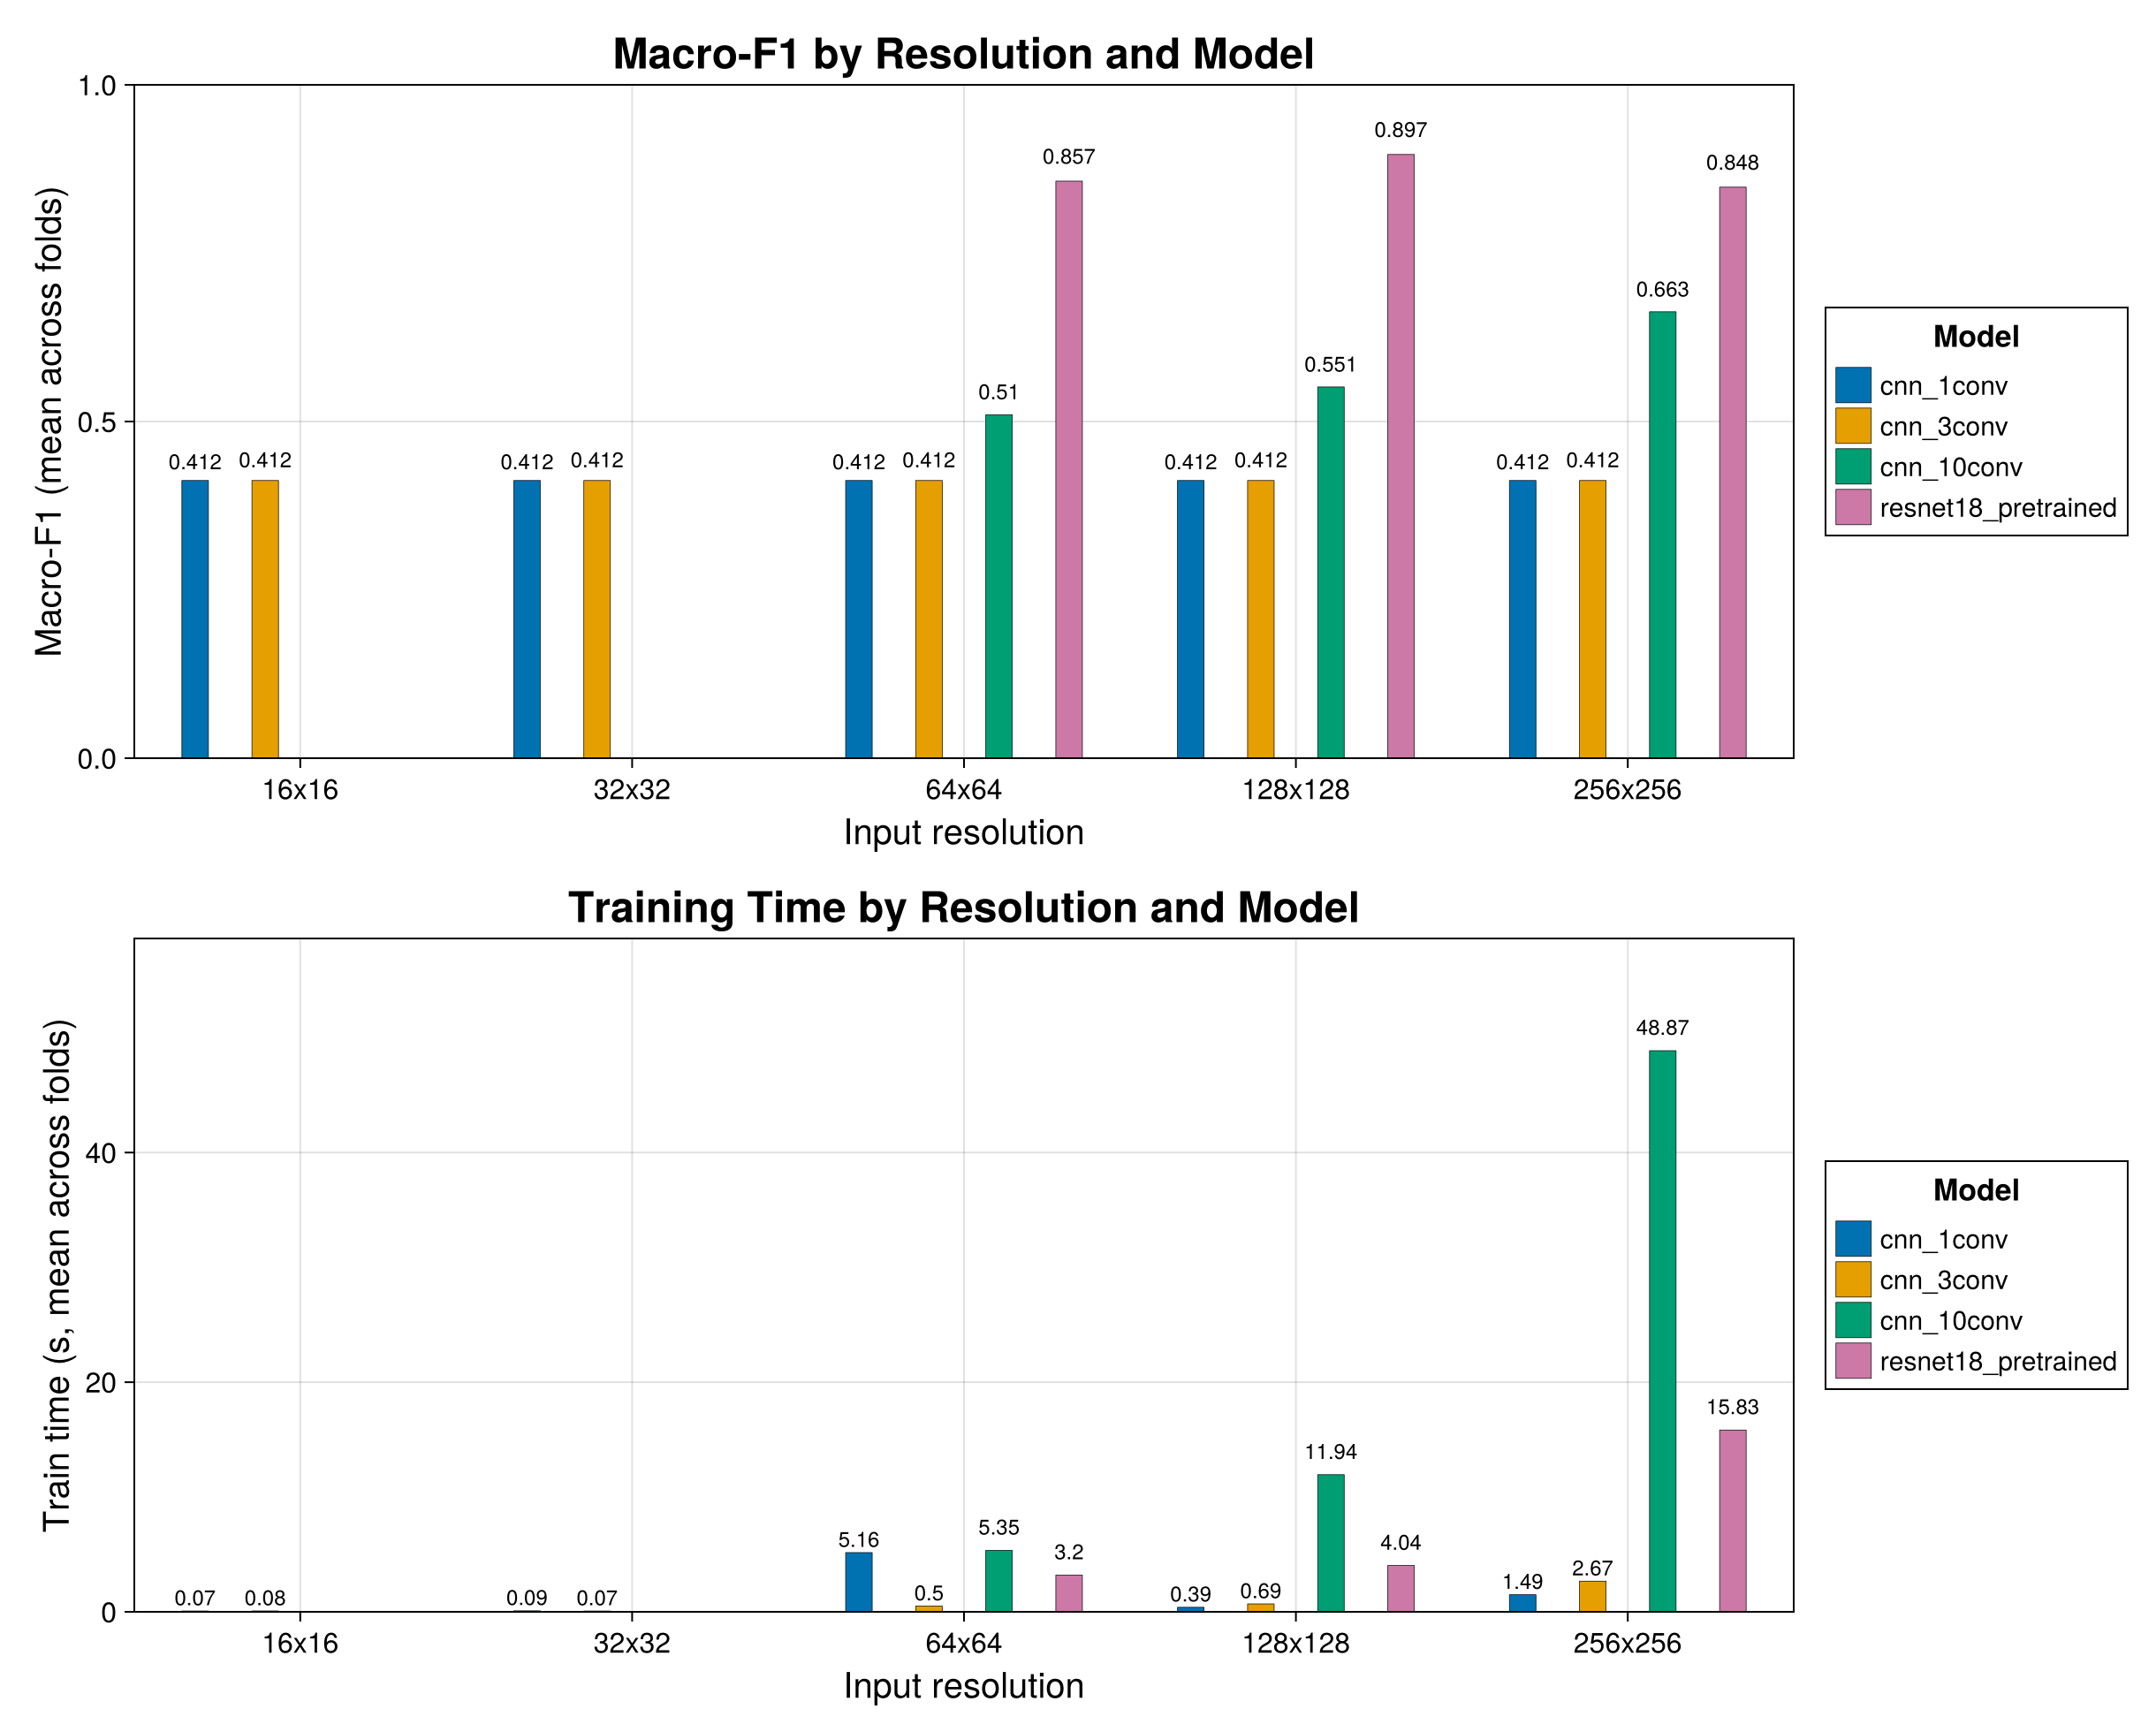

In [15]:
using CairoMakie

@assert @isdefined(summary_multisize_df) "Run cell-013 first to compute summary_multisize_df."

# Build plotting dataframe from multisize results and optionally add 64x64 baseline.
plot_source_df = summary_multisize_df[:, [:input_size, :input_h, :input_w, :model_name, :macro_f1_mean]]

if @isdefined(summary_df)
    baseline_64_df = summary_df[:, [:model_name, :macro_f1_mean]]
    baseline_64_df.input_size = fill("64x64", nrow(baseline_64_df))
    baseline_64_df.input_h = fill(64, nrow(baseline_64_df))
    baseline_64_df.input_w = fill(64, nrow(baseline_64_df))
    baseline_64_df = baseline_64_df[:, [:input_size, :input_h, :input_w, :model_name, :macro_f1_mean]]
    plot_source_df = vcat(plot_source_df, baseline_64_df)
else
    @warn "summary_df not found. 64x64 baseline could not be added to the plot."
end

rename!(plot_source_df, :macro_f1_mean => :mean_macro_f1)
sort!(plot_source_df, [:input_h, :model_name])

println("\nMean macro-F1 by input resolution and model (including 64x64 baseline):")
pretty_table(plot_source_df; table_kwargs_multisize...)

# Critical diagnostic: check if cnn_1conv and cnn_3conv are effectively identical.
cnn_compare_rows = plot_source_df[in.(String.(plot_source_df.model_name), Ref(["cnn_1conv", "cnn_3conv"])), :]
if nrow(cnn_compare_rows) > 0
    cnn_compare_wide_df = unstack(
        cnn_compare_rows[:, [:input_size, :input_h, :model_name, :mean_macro_f1]],
        :model_name,
        :mean_macro_f1,
    )
    sort!(cnn_compare_wide_df, :input_h)

    c1_col = "cnn_1conv"
    c3_col = "cnn_3conv"

    if c1_col in names(cnn_compare_wide_df) && c3_col in names(cnn_compare_wide_df)
        cnn_compare_wide_df.delta_abs = abs.(cnn_compare_wide_df[!, c1_col] .- cnn_compare_wide_df[!, c3_col])

        println("\nCritical check: cnn_1conv vs cnn_3conv macro-F1 by resolution")
        pretty_table(cnn_compare_wide_df; table_kwargs_multisize...)

        max_delta = maximum(cnn_compare_wide_df.delta_abs)
        if max_delta < 1e-6
            println("\nCritical note: cnn_1conv and cnn_3conv are numerically identical across all shown resolutions.")
            println("This usually indicates both models collapsed to a very similar decision rule (often majority-class prediction), not necessarily a plotting bug.")
        elseif max_delta < 1e-3
            println("\nCritical note: cnn_1conv and cnn_3conv are almost identical (very small deltas).")
            println("This still suggests limited additional benefit from deeper architecture on the current setup.")
        end
    end
end

# Build training-time dataframe with the same resolution set (including 64x64 baseline).
train_time_source_df = summary_multisize_df[:, [:input_size, :input_h, :input_w, :model_name, :train_time_mean_s]]
if @isdefined(summary_df)
    baseline_64_time_df = summary_df[:, [:model_name, :train_time_mean_s]]
    baseline_64_time_df.input_size = fill("64x64", nrow(baseline_64_time_df))
    baseline_64_time_df.input_h = fill(64, nrow(baseline_64_time_df))
    baseline_64_time_df.input_w = fill(64, nrow(baseline_64_time_df))
    baseline_64_time_df = baseline_64_time_df[:, [:input_size, :input_h, :input_w, :model_name, :train_time_mean_s]]
    train_time_source_df = vcat(train_time_source_df, baseline_64_time_df)
end
sort!(train_time_source_df, [:input_h, :model_name])

println("\nMean training time by input resolution and model (including 64x64 baseline):")
pretty_table(train_time_source_df; table_kwargs_multisize...)

size_df = unique(plot_source_df[:, [:input_size, :input_h]])
sort!(size_df, :input_h)
size_labels = String.(size_df.input_size)

# Keep resolution groups closer together than default integer spacing.
x_centers = [0.85 + 0.60 * (i - 1) for i in 1:length(size_labels)]
size_to_center = Dict(size_labels[i] => x_centers[i] for i in eachindex(size_labels))

model_levels = if @isdefined(MODEL_SPECS)
    [spec.name for spec in MODEL_SPECS if any(plot_source_df.model_name .== spec.name)]
else
    sort(unique(String.(plot_source_df.model_name)))
end

n_models = length(model_levels)
offset_span = 0.38
model_offsets = n_models <= 1 ? [0.0] : collect(range(-offset_span / 2, offset_span / 2, length = n_models))
bar_width = 0.06  # narrow bars
colors = Makie.wong_colors()

fig = Figure(size = (1220, 980))

# --- Top panel: macro-F1 ---
ax_f1 = Axis(
    fig[1, 1],
    title = "Macro-F1 by Resolution and Model",
    xlabel = "Input resolution",
    ylabel = "Macro-F1 (mean across folds)",
    xticks = (x_centers, size_labels),
    titlesize = 24,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 16,
    yticklabelsize = 16,
)

for (j, model_name) in enumerate(model_levels)
    idx = findall(==(model_name), String.(plot_source_df.model_name))
    isempty(idx) && continue

    x_base = [size_to_center[String(plot_source_df.input_size[i])] for i in idx]
    xj = x_base .+ model_offsets[j]
    yj = Float64.(plot_source_df.mean_macro_f1[idx])

    barplot!(
        ax_f1,
        xj,
        yj;
        color = colors[((j - 1) % length(colors)) + 1],
        width = bar_width,
        strokecolor = :black,
        strokewidth = 0.35,
        label = model_name,
    )

    text!(
        ax_f1,
        xj,
        yj .+ 0.010 .+ 0.003 * (j - 1),
        text = string.(round.(yj, digits = 3)),
        align = (:center, :bottom),
        fontsize = 12,
        color = :black,
    )
end

ylims!(ax_f1, 0, 1)
xlims!(ax_f1, minimum(x_centers) - 0.30, maximum(x_centers) + 0.30)
Legend(fig[1, 2], ax_f1, "Model"; labelsize = 15, titlesize = 17)

# --- Bottom panel: training time ---
ax_t = Axis(
    fig[2, 1],
    title = "Training Time by Resolution and Model",
    xlabel = "Input resolution",
    ylabel = "Train time (s, mean across folds)",
    xticks = (x_centers, size_labels),
    titlesize = 24,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 16,
    yticklabelsize = 16,
)

all_time_vals = Float64[]
for (j, model_name) in enumerate(model_levels)
    idx = findall(==(model_name), String.(train_time_source_df.model_name))
    isempty(idx) && continue

    x_base = [size_to_center[String(train_time_source_df.input_size[i])] for i in idx]
    xj = x_base .+ model_offsets[j]
    yj = Float64.(train_time_source_df.train_time_mean_s[idx])
    append!(all_time_vals, yj)

    barplot!(
        ax_t,
        xj,
        yj;
        color = colors[((j - 1) % length(colors)) + 1],
        width = bar_width,
        strokecolor = :black,
        strokewidth = 0.35,
        label = model_name,
    )

    text!(
        ax_t,
        xj,
        yj .+ 0.02 * max(maximum(all_time_vals), 1.0),
        text = string.(round.(yj, digits = 2)),
        align = (:center, :bottom),
        fontsize = 12,
        color = :black,
    )
end

max_time = isempty(all_time_vals) ? 1.0 : maximum(all_time_vals)
ylims!(ax_t, 0, max(1.0, max_time * 1.20))
xlims!(ax_t, minimum(x_centers) - 0.30, maximum(x_centers) + 0.30)
Legend(fig[2, 2], ax_t, "Model"; labelsize = 15, titlesize = 17)

fig


In [16]:
# ResNet18 bias diagnostics on the 64x64 setup:
# - aggregated confusion matrix across all validation folds
# - per-sort-variable statistics to inspect potential bias patterns

@assert @isdefined(MODEL_SPECS) "Run model setup cells first."
@assert @isdefined(train_df) "Run dataset preparation cells first."
@assert @isdefined(X_rgb) && @isdefined(y_binary) && @isdefined(group_ids) "Run tensor construction cells first."
@assert @isdefined(k_folds) "Run fold configuration cell first."

resnet_spec_idx = findfirst(spec -> spec.name == "resnet18_pretrained", MODEL_SPECS)
@assert !isnothing(resnet_spec_idx) "Could not find MODEL_SPECS entry for resnet18_pretrained."
resnet_spec = MODEL_SPECS[resnet_spec_idx]

sort_vars_diag = String.(train_df.sort_var)
fold_val_indices_diag = make_group_kfolds(group_ids, y_binary, sort_vars_diag, k_folds; seed = 20260220)

println("\n", repeat("=", 96))
println("ResNet18 diagnostics (64x64): confusion matrix and sort-variable bias analysis")
println(repeat("=", 96))

resnet18_diag_rows = NamedTuple[]
resnet18_fold_rows = NamedTuple[]

for (fold_id, val_idx) in enumerate(fold_val_indices_diag)
    n = size(X_rgb, 4)
    train_mask = trues(n)
    train_mask[val_idx] .= false
    train_idx = findall(train_mask)

    X_train = X_rgb[:, :, :, train_idx]
    y_train = onehotbatch(y_binary[train_idx], 0:1) |> Array{Float32}

    X_val = X_rgb[:, :, :, val_idx]
    y_val = onehotbatch(y_binary[val_idx], 0:1) |> Array{Float32}

    train_loader = DataLoader((X_train, y_train); batchsize = resnet_spec.batchsize, shuffle = true)
    val_loader = DataLoader((X_val, y_val); batchsize = resnet_spec.batchsize, shuffle = false)

    CUDA.reclaim()

    model, pretrain_matched = resnet_spec.builder()
    model = device(model)

    model, train_time_s = train_one_fold!(
        model,
        train_loader;
        nepochs = resnet_spec.nepochs,
        lr = resnet_spec.lr,
        model_name = "resnet18_pretrained_diag",
        fold_id = fold_id,
    )

    y_true_fold = Int[]
    y_pred_fold = Int[]

    val_time_s = @elapsed begin
        for (xb_cpu, yb_cpu) in val_loader
            logits = cpu(model(device(xb_cpu)))
            append!(y_pred_fold, onecold(logits, 0:1))
            append!(y_true_fold, onecold(yb_cpu, 0:1))
        end
    end

    fold_metrics = compute_metrics(y_pred_fold, y_true_fold)

    push!(resnet18_fold_rows, (
        fold = fold_id,
        n_train = length(train_idx),
        n_val = length(val_idx),
        accuracy = fold_metrics.accuracy,
        balanced_accuracy = fold_metrics.balanced_accuracy,
        macro_f1 = fold_metrics.macro_f1,
        precision = fold_metrics.precision,
        recall = fold_metrics.recall,
        train_time_s = train_time_s,
        val_time_s = val_time_s,
        total_time_s = train_time_s + val_time_s,
        pretrained_params_loaded = pretrain_matched,
    ))

    @assert length(y_true_fold) == length(val_idx) "Validation predictions and indices must align."

    for j in eachindex(val_idx)
        sample_idx = val_idx[j]
        yt = y_true_fold[j]
        yp = y_pred_fold[j]
        push!(resnet18_diag_rows, (
            fold = fold_id,
            sample_idx = sample_idx,
            group_id = group_ids[sample_idx],
            sort_var = sort_vars_diag[sample_idx],
            y_true = yt,
            y_pred = yp,
            correct = Int(yt == yp),
        ))
    end

    CUDA.reclaim()
    GC.gc(true)
end

resnet18_diag_df = DataFrame(resnet18_diag_rows)
resnet18_fold_perf_df = DataFrame(resnet18_fold_rows)
sort!(resnet18_fold_perf_df, :fold)

println("\nFold-level diagnostic performance (resnet18_pretrained):")
pretty_table(resnet18_fold_perf_df; table_kwargs...)

safe_div(a, b) = b == 0 ? NaN : a / b

tp = count((resnet18_diag_df.y_true .== 1) .& (resnet18_diag_df.y_pred .== 1))
tn = count((resnet18_diag_df.y_true .== 0) .& (resnet18_diag_df.y_pred .== 0))
fp = count((resnet18_diag_df.y_true .== 0) .& (resnet18_diag_df.y_pred .== 1))
fn = count((resnet18_diag_df.y_true .== 1) .& (resnet18_diag_df.y_pred .== 0))

confusion_counts_df = DataFrame(
    true_label = ["no_class (0)", "class (1)"],
    pred_no_class = [tn, fn],
    pred_class = [fp, tp],
    support = [tn + fp, fn + tp],
)

confusion_rates_df = DataFrame(
    true_label = ["no_class (0)", "class (1)"],
    pred_no_class_rate = [safe_div(tn, tn + fp), safe_div(fn, fn + tp)],
    pred_class_rate = [safe_div(fp, tn + fp), safe_div(tp, fn + tp)],
)

overall_acc = safe_div(tp + tn, tp + tn + fp + fn)
overall_tpr = safe_div(tp, tp + fn)
overall_tnr = safe_div(tn, tn + fp)
overall_balacc = isnan(overall_tpr) || isnan(overall_tnr) ? NaN : (overall_tpr + overall_tnr) / 2
overall_f1_pos = safe_div(2 * tp, 2 * tp + fp + fn)
overall_f1_neg = safe_div(2 * tn, 2 * tn + fp + fn)
overall_macro_f1 = isnan(overall_f1_pos) || isnan(overall_f1_neg) ? NaN : (overall_f1_pos + overall_f1_neg) / 2

overall_diag_df = DataFrame(
    metric = [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "true_positive_rate",
        "true_negative_rate",
        "predicted_positive_rate",
        "true_positive_prevalence",
    ],
    value = [
        overall_acc,
        overall_balacc,
        overall_macro_f1,
        overall_tpr,
        overall_tnr,
        safe_div(tp + fp, tp + tn + fp + fn),
        safe_div(tp + fn, tp + tn + fp + fn),
    ],
)

println("\nAggregated confusion matrix counts (all folds combined):")
pretty_table(confusion_counts_df; table_kwargs...)

println("\nAggregated confusion matrix row-normalized rates:")
pretty_table(confusion_rates_df; table_kwargs...)

println("\nOverall diagnostic metrics from aggregated confusion counts:")
pretty_table(overall_diag_df; table_kwargs...)

sort_var_diag_df = combine(groupby(resnet18_diag_df, :sort_var)) do sdf
    tp_sv = count((sdf.y_true .== 1) .& (sdf.y_pred .== 1))
    tn_sv = count((sdf.y_true .== 0) .& (sdf.y_pred .== 0))
    fp_sv = count((sdf.y_true .== 0) .& (sdf.y_pred .== 1))
    fn_sv = count((sdf.y_true .== 1) .& (sdf.y_pred .== 0))

    n = nrow(sdf)
    true_pos = tp_sv + fn_sv
    pred_pos = tp_sv + fp_sv

    tpr_sv = safe_div(tp_sv, tp_sv + fn_sv)
    tnr_sv = safe_div(tn_sv, tn_sv + fp_sv)
    balacc_sv = isnan(tpr_sv) || isnan(tnr_sv) ? NaN : (tpr_sv + tnr_sv) / 2

    f1_pos_sv = safe_div(2 * tp_sv, 2 * tp_sv + fp_sv + fn_sv)
    f1_neg_sv = safe_div(2 * tn_sv, 2 * tn_sv + fp_sv + fn_sv)
    macro_f1_sv = isnan(f1_pos_sv) || isnan(f1_neg_sv) ? NaN : (f1_pos_sv + f1_neg_sv) / 2

    pred_pos_rate_sv = safe_div(pred_pos, n)
    true_pos_rate_sv = safe_div(true_pos, n)

    (
        n = n,
        tp = tp_sv,
        tn = tn_sv,
        fp = fp_sv,
        fn = fn_sv,
        true_pos_rate = true_pos_rate_sv,
        pred_pos_rate = pred_pos_rate_sv,
        bias_delta_pred_minus_true_pos = pred_pos_rate_sv - true_pos_rate_sv,
        accuracy = safe_div(tp_sv + tn_sv, n),
        balanced_accuracy = balacc_sv,
        macro_f1 = macro_f1_sv,
    )
end

sort_var_diag_df.abs_bias_delta = abs.(sort_var_diag_df.bias_delta_pred_minus_true_pos)
sort!(sort_var_diag_df, :sort_var)

bias_rank_df = sort(sort_var_diag_df, :abs_bias_delta, rev = true)

println("\nPer-sort-variable diagnostics (bias and performance):")
pretty_table(sort_var_diag_df; table_kwargs...)

println("\nPer-sort-variable bias ranking (largest |pred_pos_rate - true_pos_rate| first):")
pretty_table(bias_rank_df[:, [:sort_var, :n, :true_pos_rate, :pred_pos_rate, :bias_delta_pred_minus_true_pos, :accuracy, :balanced_accuracy, :macro_f1]]; table_kwargs...)

# Keep detailed row-level diagnostics available in `resnet18_diag_df` without auto-printing it.
nothing



ResNet18 diagnostics (64x64): confusion matrix and sort-variable bias analysis


[ Info: resnet18_pretrained_diag | fold 1 | epoch 1/8 | train_loss=0.56559
[ Info: resnet18_pretrained_diag | fold 1 | epoch 2/8 | train_loss=0.54337
[ Info: resnet18_pretrained_diag | fold 1 | epoch 3/8 | train_loss=0.25395
[ Info: resnet18_pretrained_diag | fold 1 | epoch 4/8 | train_loss=0.09119
[ Info: resnet18_pretrained_diag | fold 1 | epoch 5/8 | train_loss=0.23908
[ Info: resnet18_pretrained_diag | fold 1 | epoch 6/8 | train_loss=0.08839
[ Info: resnet18_pretrained_diag | fold 1 | epoch 7/8 | train_loss=0.01628
[ Info: resnet18_pretrained_diag | fold 1 | epoch 8/8 | train_loss=0.01205
[ Info: resnet18_pretrained_diag | fold 2 | epoch 1/8 | train_loss=0.55694
[ Info: resnet18_pretrained_diag | fold 2 | epoch 2/8 | train_loss=0.18644
[ Info: resnet18_pretrained_diag | fold 2 | epoch 3/8 | train_loss=0.40691
[ Info: resnet18_pretrained_diag | fold 2 | epoch 4/8 | train_loss=0.31527
[ Info: resnet18_pretrained_diag | fold 2 | epoch 5/8 | train_loss=0.12581
[ Info: resnet18_pretrain


Fold-level diagnostic performance (resnet18_pretrained):
┌───────┬─────────┬───────┬──────────┬───────────────────┬──────────┬───────────┬──────────┬──────────────┬────────────┬──────────────┬──────────────────────────┐
│  fold │ n_train │ n_val │ accuracy │ balanced_accuracy │ macro_f1 │ precision │   recall │ train_time_s │ val_time_s │ total_time_s │ pretrained_params_loaded │
│ Int64 │   Int64 │ Int64 │  Float64 │           Float64 │  Float64 │   Float64 │  Float64 │      Float64 │    Float64 │      Float64 │                    Int64 │
├───────┼─────────┼───────┼──────────┼───────────────────┼──────────┼───────────┼──────────┼──────────────┼────────────┼──────────────┼──────────────────────────┤
│     1 │     513 │   131 │ 0.870229 │           0.84635 │ 0.843664 │  0.841137 │  0.84635 │      1.08528 │  0.0370188 │       1.1223 │                       62 │
│     2 │     513 │   131 │  0.89313 │          0.901387 │ 0.877341 │  0.862788 │ 0.901387 │      1.06107 │ 0.00917019 │      1

# Additional Data Processing Experiments (64x64)

The cells below add three extra tests on the same 64x64 ERP images and keep 5-fold group cross-validation with all four models.


In [17]:
using CairoMakie

exp_table_kwargs = @isdefined(table_kwargs) ? table_kwargs : (
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    display_size = (10_000, 10_000),
    show_omitted_cell_summary = false,
)

function print_dataset_statistics(df::DataFrame; title::String)
    n_total = nrow(df)
    n_pos = count(==(1), Int.(df.binary_label))
    n_neg = count(==(0), Int.(df.binary_label))

    stats_df = DataFrame(
        metric = [
            "samples_total",
            "samples_class",
            "samples_no_class",
            "unique_source_groups",
            "mean_trials_per_sample",
            "median_trials_per_sample",
        ],
        value = [
            n_total,
            n_pos,
            n_neg,
            length(unique(Int.(df.group_id))),
            round(mean(Float64.(df.n_trials)); digits = 3),
            round(median(Float64.(df.n_trials)); digits = 3),
        ],
    )

    label_sort_df = combine(
        groupby(df, [:binary_label, :sort_var]),
        nrow => :count,
        :n_trials => mean => :mean_trials,
        :n_trials => minimum => :min_trials,
        :n_trials => maximum => :max_trials,
    )
    sort!(label_sort_df, [:binary_label, :sort_var])

    println("\n", title)
    pretty_table(stats_df; exp_table_kwargs...)

    println("\nLabel x sort-variable distribution:")
    pretty_table(label_sort_df; exp_table_kwargs...)

    return stats_df, label_sort_df
end

function apply_quantile_clip_01_99(df::DataFrame)
    out_df = copy(df)
    clipped_imgs = Matrix{Float32}[]
    rows = NamedTuple[]

    for i in 1:nrow(df)
        img = Float32.(df.processed_img[i])
        vals = vec(Float64.(img))
        q01 = quantile(vals, 0.01)
        q99 = quantile(vals, 0.99)

        clipped = clamp.(img, Float32(q01), Float32(q99))

        frac_low = count(<(Float32(q01)), img) / length(img)
        frac_high = count(>(Float32(q99)), img) / length(img)

        push!(clipped_imgs, clipped)
        push!(rows, (
            sample_id = Int(df.sample_id[i]),
            binary_label = Int(df.binary_label[i]),
            sort_var = String(df.sort_var[i]),
            q01 = q01,
            q99 = q99,
            frac_low_clipped = frac_low,
            frac_high_clipped = frac_high,
        ))
    end

    out_df.processed_img = clipped_imgs
    clip_stats_df = DataFrame(rows)
    return out_df, clip_stats_df
end

function apply_minmax_minus1_1(df::DataFrame)
    out_df = copy(df)
    scaled_imgs = Matrix{Float32}[]
    rows = NamedTuple[]

    for i in 1:nrow(df)
        img = Float32.(df.processed_img[i])
        mn = minimum(img)
        mx = maximum(img)
        rng = mx - mn

        scaled = if rng > 0f0
            @. (2f0 * ((img - mn) / rng)) - 1f0
        else
            fill(0f0, size(img))
        end

        push!(scaled_imgs, scaled)
        push!(rows, (
            sample_id = Int(df.sample_id[i]),
            binary_label = Int(df.binary_label[i]),
            sort_var = String(df.sort_var[i]),
            min_before = Float64(mn),
            max_before = Float64(mx),
            min_after = Float64(minimum(scaled)),
            max_after = Float64(maximum(scaled)),
        ))
    end

    out_df.processed_img = scaled_imgs
    scale_stats_df = DataFrame(rows)
    return out_df, scale_stats_df
end

function build_class_balanced_no_class_subset(df::DataFrame; seed::Int = 20260315)
    pos_df = copy(df[Int.(df.binary_label) .== 1, :])
    neg_df = copy(df[Int.(df.binary_label) .== 0, :])

    n_target_neg = nrow(pos_df)
    @assert n_target_neg <= nrow(neg_df) "Not enough no-class samples to match class count."

    rng = MersenneTwister(seed)

    neg_sort = String.(neg_df.sort_var)
    sort_levels = sort(unique(neg_sort))
    pools = Dict{String, Vector{Int}}()

    for sv in sort_levels
        idxs = findall(==(sv), neg_sort)
        pools[sv] = shuffle(rng, idxs)
    end

    ptr = Dict(sv => 1 for sv in sort_levels)
    selected_rel = Int[]

    while length(selected_rel) < n_target_neg
        progressed = false
        for sv in sort_levels
            p = ptr[sv]
            ids = pools[sv]
            if p <= length(ids)
                push!(selected_rel, ids[p])
                ptr[sv] = p + 1
                progressed = true
                length(selected_rel) >= n_target_neg && break
            end
        end
        progressed || break
    end

    @assert length(selected_rel) == n_target_neg "Could not draw enough no-class samples with round-robin over sort variables."

    kept_neg_df = copy(neg_df[selected_rel, :])

    out_df = vcat(pos_df, kept_neg_df; cols = :union)
    perm = randperm(rng, nrow(out_df))
    out_df = copy(out_df[perm, :])
    out_df.sample_id = collect(1:nrow(out_df))

    before_counts = combine(groupby(neg_df, :sort_var), nrow => :no_class_before)
    kept_counts = combine(groupby(kept_neg_df, :sort_var), nrow => :no_class_kept)

    keep_stats_df = outerjoin(before_counts, kept_counts, on = :sort_var)
    keep_stats_df.no_class_before = Int.(coalesce.(keep_stats_df.no_class_before, 0))
    keep_stats_df.no_class_kept = Int.(coalesce.(keep_stats_df.no_class_kept, 0))
    keep_stats_df.no_class_dropped = keep_stats_df.no_class_before .- keep_stats_df.no_class_kept
    sort!(keep_stats_df, :sort_var)

    return out_df, keep_stats_df
end

function run_cv_experiment_64(df::DataFrame; experiment_name::String, seed::Int = 20260320)
    @assert nrow(df) > 0
    @assert size(df.processed_img[1]) == (64, 64) "This experiment expects 64x64 processed matrices."

    X_gray_local = images_to_tensor(df.processed_img)
    X_rgb_local = repeat(X_gray_local, 1, 1, 3, 1)
    y_local = Int.(df.binary_label)
    group_local = Int.(df.group_id)
    sort_local = String.(df.sort_var)

    folds_local = make_group_kfolds(group_local, y_local, sort_local, k_folds; seed = seed)

    fold_rows = NamedTuple[]
    fold_sort_rows = NamedTuple[]
    for (fold, val_idx) in enumerate(folds_local)
        y_fold = y_local[val_idx]
        push!(fold_rows, (
            fold = fold,
            n_val = length(val_idx),
            n_pos = count(==(1), y_fold),
            n_neg = count(==(0), y_fold),
        ))

        sv_df = combine(groupby(DataFrame(sort_var = sort_local[val_idx]), :sort_var), nrow => :count)
        sort!(sv_df, :sort_var)
        for r in eachrow(sv_df)
            push!(fold_sort_rows, (fold = fold, sort_var = String(r.sort_var), count = Int(r.count)))
        end
    end

    fold_stats_df = DataFrame(fold_rows)
    fold_sort_stats_df = DataFrame(fold_sort_rows)
    sort!(fold_sort_stats_df, [:fold, :sort_var])

    println("\n", repeat("=", 98))
    println("Experiment: ", experiment_name)
    println(repeat("=", 98))

    println("\nFold label distribution:")
    pretty_table(fold_stats_df; exp_table_kwargs...)

    println("\nFold sort-variable distribution:")
    pretty_table(fold_sort_stats_df; exp_table_kwargs...)

    cv_rows_local = DataFrame[]

    for spec in MODEL_SPECS
        X_use = spec.input_type == :rgb ? X_rgb_local : X_gray_local

        println("\n", repeat("-", 88))
        println("Running model: ", spec.name, " | experiment=", experiment_name)
        println("  input_type=", spec.input_type,
                " | nepochs=", spec.nepochs,
                " | lr=", spec.lr,
                " | batchsize=", spec.batchsize)
        println(repeat("-", 88))

        df_model = run_model_cv(
            spec.name,
            spec.builder,
            X_use,
            y_local,
            folds_local;
            nepochs = spec.nepochs,
            lr = spec.lr,
            batchsize = spec.batchsize,
            is_pretrained = spec.is_pretrained,
        )

        push!(cv_rows_local, df_model)
    end

    cv_df = vcat(cv_rows_local...)
    sort!(cv_df, [:model_name, :fold])

    println("\nFold-level performance:")
    pretty_table(
        cv_df[:, [:model_name, :fold, :n_train, :n_val, :accuracy, :balanced_accuracy, :macro_f1, :train_time_s, :val_time_s, :total_time_s, :params_n, :pretrained_params_loaded]];
        exp_table_kwargs...,
    )

    summary_df_local = combine(
        groupby(cv_df, :model_name),
        :accuracy => mean => :accuracy_mean,
        :accuracy => std => :accuracy_std,
        :balanced_accuracy => mean => :balanced_accuracy_mean,
        :balanced_accuracy => std => :balanced_accuracy_std,
        :macro_f1 => mean => :macro_f1_mean,
        :macro_f1 => std => :macro_f1_std,
        :precision => mean => :precision_mean,
        :recall => mean => :recall_mean,
        :train_time_s => mean => :train_time_mean_s,
        :train_time_s => std => :train_time_std_s,
        :val_time_s => mean => :val_time_mean_s,
        :val_time_s => std => :val_time_std_s,
        :total_time_s => mean => :total_time_mean_s,
        :total_time_s => std => :total_time_std_s,
        :params_n => first => :params_n,
        :pretrained_params_loaded => maximum => :pretrained_params_loaded,
    )
    sort!(summary_df_local, :model_name)

    println("\nModel summary (mean ± std across 5 folds):")
    pretty_table(summary_df_local; exp_table_kwargs...)

    single_value_df = combine(
        groupby(cv_df, :model_name),
        :accuracy => mean => :accuracy,
        :balanced_accuracy => mean => :balanced_accuracy,
        :macro_f1 => mean => :macro_f1,
        :precision => mean => :precision,
        :recall => mean => :recall,
        :train_time_s => mean => :train_time_s,
        :val_time_s => mean => :val_time_s,
        :total_time_s => mean => :total_time_s,
        :params_n => first => :params_n,
        :pretrained_params_loaded => maximum => :pretrained_params_loaded,
    )
    sort!(single_value_df, :model_name)

    println("\nSingle-value summary (mean across folds):")
    pretty_table(single_value_df; exp_table_kwargs...)

    return (
        cv_results = cv_df,
        summary = summary_df_local,
        single_value = single_value_df,
        fold_stats = fold_stats_df,
        fold_sort_stats = fold_sort_stats_df,
    )
end


MODEL_PLOT_ORDER = ["cnn_1conv", "cnn_3conv", "cnn_10conv", "resnet18_pretrained"]

function ordered_model_names_present(model_names::Vector{String})
    present = Set(model_names)
    ordered = [m for m in MODEL_PLOT_ORDER if m in present]
    others = sort([m for m in unique(model_names) if !(m in Set(MODEL_PLOT_ORDER))])
    return vcat(ordered, others)
end

function reorder_models_for_plots(df::DataFrame)
    out = copy(df)
    names(out) == [] && return out

    model_names = String.(out.model_name)
    ordered = ordered_model_names_present(model_names)
    rank = Dict(m => i for (i, m) in enumerate(ordered))
    out._model_order = [get(rank, String(m), length(ordered) + 1) for m in out.model_name]
    sort!(out, :_model_order)
    select!(out, Not(:_model_order))

    return out
end

function plot_model_performance_bars(single_value_df::DataFrame; title::String)
    # Requested metrics for plots: balanced accuracy and macro-F1.
    metrics = [:balanced_accuracy, :macro_f1]
    metric_labels = Dict(
        :balanced_accuracy => "Balanced Accuracy",
        :macro_f1 => "Macro-F1",
    )

    plot_df = reorder_models_for_plots(single_value_df)

    model_names = String.(plot_df.model_name)
    x = collect(1:length(model_names))

    offsets = [-0.14, 0.14]
    bar_width = 0.24
    colors = [:darkorange, :seagreen]

    fig = Figure(size = (1200, 430))
    ax = Axis(
        fig[1, 1],
        title = title,
        xlabel = "Model",
        ylabel = "Score (mean across folds)",
        xticks = (x, model_names),
        xticklabelrotation = 0.20,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 16,
        yticklabelsize = 16,
    )

    for (j, metric) in enumerate(metrics)
        y = Float64.(plot_df[!, metric])
        xj = x .+ offsets[j]

        barplot!(
            ax,
            xj,
            y;
            width = bar_width,
            color = colors[j],
            strokecolor = :black,
            strokewidth = 0.35,
            label = metric_labels[metric],
        )

        text!(
            ax,
            xj,
            y .+ 0.012,
            text = string.(round.(y, digits = 3)),
            align = (:center, :bottom),
            fontsize = 12,
            color = :black,
        )
    end

    ylims!(ax, 0, 1)
    axislegend(ax; position = :rb, title = "Metric", labelsize = 15, titlesize = 17)

    fig
end


plot_model_performance_bars (generic function with 1 method)

## Experiment 1: Per-Image Quantile Clipping (1% / 99%)

This test clips each 64x64 ERP matrix individually after downscaling:
- values below the 1st percentile are clipped to the 1st percentile
- values above the 99th percentile are clipped to the 99th percentile



Quantile clipping summary (per-image clipping statistics):
┌────────────────────────┬───────────┐
│                 metric │     value │
│                 String │   Float64 │
├────────────────────────┼───────────┤
│               mean_q01 │ -0.458441 │
│               mean_q99 │  0.456238 │
│  mean_frac_low_clipped │ 0.0100098 │
│ mean_frac_high_clipped │ 0.0100098 │
└────────────────────────┴───────────┘

Quantile clipping summary by label:
┌──────────────┬───────────┬──────────┬───────────────────────┬────────────────────────┐
│ binary_label │  mean_q01 │ mean_q99 │ mean_frac_low_clipped │ mean_frac_high_clipped │
│        Int64 │   Float64 │  Float64 │               Float64 │                Float64 │
├──────────────┼───────────┼──────────┼───────────────────────┼────────────────────────┤
│            0 │   -0.4472 │ 0.451245 │             0.0100098 │              0.0100098 │
│            1 │ -0.484903 │ 0.467992 │             0.0100098 │              0.0100098 │
└──────────────┴──

[ Info: cnn_1conv | fold 1 | epoch 1/10 | train_loss=0.69443
[ Info: cnn_1conv | fold 1 | epoch 2/10 | train_loss=0.68732
[ Info: cnn_1conv | fold 1 | epoch 3/10 | train_loss=0.68311
[ Info: cnn_1conv | fold 1 | epoch 4/10 | train_loss=0.66414
[ Info: cnn_1conv | fold 1 | epoch 5/10 | train_loss=0.65664
[ Info: cnn_1conv | fold 1 | epoch 6/10 | train_loss=0.67388
[ Info: cnn_1conv | fold 1 | epoch 7/10 | train_loss=0.67095
[ Info: cnn_1conv | fold 1 | epoch 8/10 | train_loss=0.63606
[ Info: cnn_1conv | fold 1 | epoch 9/10 | train_loss=0.63096
[ Info: cnn_1conv | fold 1 | epoch 10/10 | train_loss=0.66708
[ Info: cnn_1conv | fold 2 | epoch 1/10 | train_loss=0.68497
[ Info: cnn_1conv | fold 2 | epoch 2/10 | train_loss=0.68401
[ Info: cnn_1conv | fold 2 | epoch 3/10 | train_loss=0.65391
[ Info: cnn_1conv | fold 2 | epoch 4/10 | train_loss=0.67374
[ Info: cnn_1conv | fold 2 | epoch 5/10 | train_loss=0.63776
[ Info: cnn_1conv | fold 2 | epoch 6/10 | train_loss=0.63001
[ Info: cnn_1conv | fol


----------------------------------------------------------------------------------------

[ Info: cnn_1conv | fold 5 | epoch 1/10 | train_loss=0.69719
[ Info: cnn_1conv | fold 5 | epoch 2/10 | train_loss=0.67793
[ Info: cnn_1conv | fold 5 | epoch 3/10 | train_loss=0.66202
[ Info: cnn_1conv | fold 5 | epoch 4/10 | train_loss=0.65022
[ Info: cnn_1conv | fold 5 | epoch 5/10 | train_loss=0.63443
[ Info: cnn_1conv | fold 5 | epoch 6/10 | train_loss=0.64754
[ Info: cnn_1conv | fold 5 | epoch 7/10 | train_loss=0.61912
[ Info: cnn_1conv | fold 5 | epoch 8/10 | train_loss=0.64198
[ Info: cnn_1conv | fold 5 | epoch 9/10 | train_loss=0.62025
[ Info: cnn_1conv | fold 5 | epoch 10/10 | train_loss=0.61856



Running model: cnn_3conv | experiment=64x64 | Per-image quantile clipping (1%/99%)
  input_type=gray | nepochs=10 | lr=0.001 | batchsize=64
----------------------------------------------------------------------------------------


...


----------------------------------------------------------------------------------------
Running model: resnet18_pretrained | experiment=64x64 | Per-image quantile clipping (1%/99%)
  input_type=rgb | nepochs=8 | lr=0.0003 | batchsize=32
----------------------------------------------------------------------------------------


[ Info: resnet18_pretrained | fold 1 | epoch 1/8 | train_loss=0.70668
[ Info: resnet18_pretrained | fold 1 | epoch 2/8 | train_loss=0.3915
[ Info: resnet18_pretrained | fold 1 | epoch 3/8 | train_loss=0.10592
[ Info: resnet18_pretrained | fold 1 | epoch 4/8 | train_loss=0.1288
[ Info: resnet18_pretrained | fold 1 | epoch 5/8 | train_loss=0.06605
[ Info: resnet18_pretrained | fold 1 | epoch 6/8 | train_loss=0.23722
[ Info: resnet18_pretrained | fold 1 | epoch 7/8 | train_loss=0.05135
[ Info: resnet18_pretrained | fold 1 | epoch 8/8 | train_loss=0.18546
[ Info: resnet18_pretrained | fold 2 | epoch 1/8 | train_loss=0.78328
[ Info: resnet18_pretrained | fold 2 | epoch 2/8 | train_loss=0.43004
[ Info: resnet18_pretrained | fold 2 | epoch 3/8 | train_loss=0.33219
[ Info: resnet18_pretrained | fold 2 | epoch 4/8 | train_loss=0.2907
[ Info: resnet18_pretrained | fold 2 | epoch 5/8 | train_loss=0.11035
[ Info: resnet18_pretrained | fold 2 | epoch 6/8 | train_loss=0.18327
[ Info: resnet18_pretra


Fold-level performance:


[ Info: resnet18_pretrained | fold 5 | epoch 8/8 | train_loss=0.19131


┌─────────────────────┬───────┬─────────┬───────┬──────────┬───────────────────┬──────────┬──────────────┬─────────────┬──────────────┬──────────┬──────────────────────────┐
│          model_name │  fold │ n_train │ n_val │ accuracy │ balanced_accuracy │ macro_f1 │ train_time_s │  val_time_s │ total_time_s │ params_n │ pretrained_params_loaded │
│              String │ Int64 │   Int64 │ Int64 │  Float64 │           Float64 │  Float64 │      Float64 │     Float64 │      Float64 │    Int64 │                    Int64 │
├─────────────────────┼───────┼─────────┼───────┼──────────┼───────────────────┼──────────┼──────────────┼─────────────┼──────────────┼──────────┼──────────────────────────┤
│          cnn_10conv │     1 │     513 │   131 │  0.59542 │          0.715054 │ 0.595326 │      3.12555 │   0.0224774 │      3.14803 │    84258 │                        0 │
│          cnn_10conv │     2 │     513 │   131 │ 0.832061 │          0.710526 │ 0.743412 │      3.15317 │   0.0271359 │      3.18

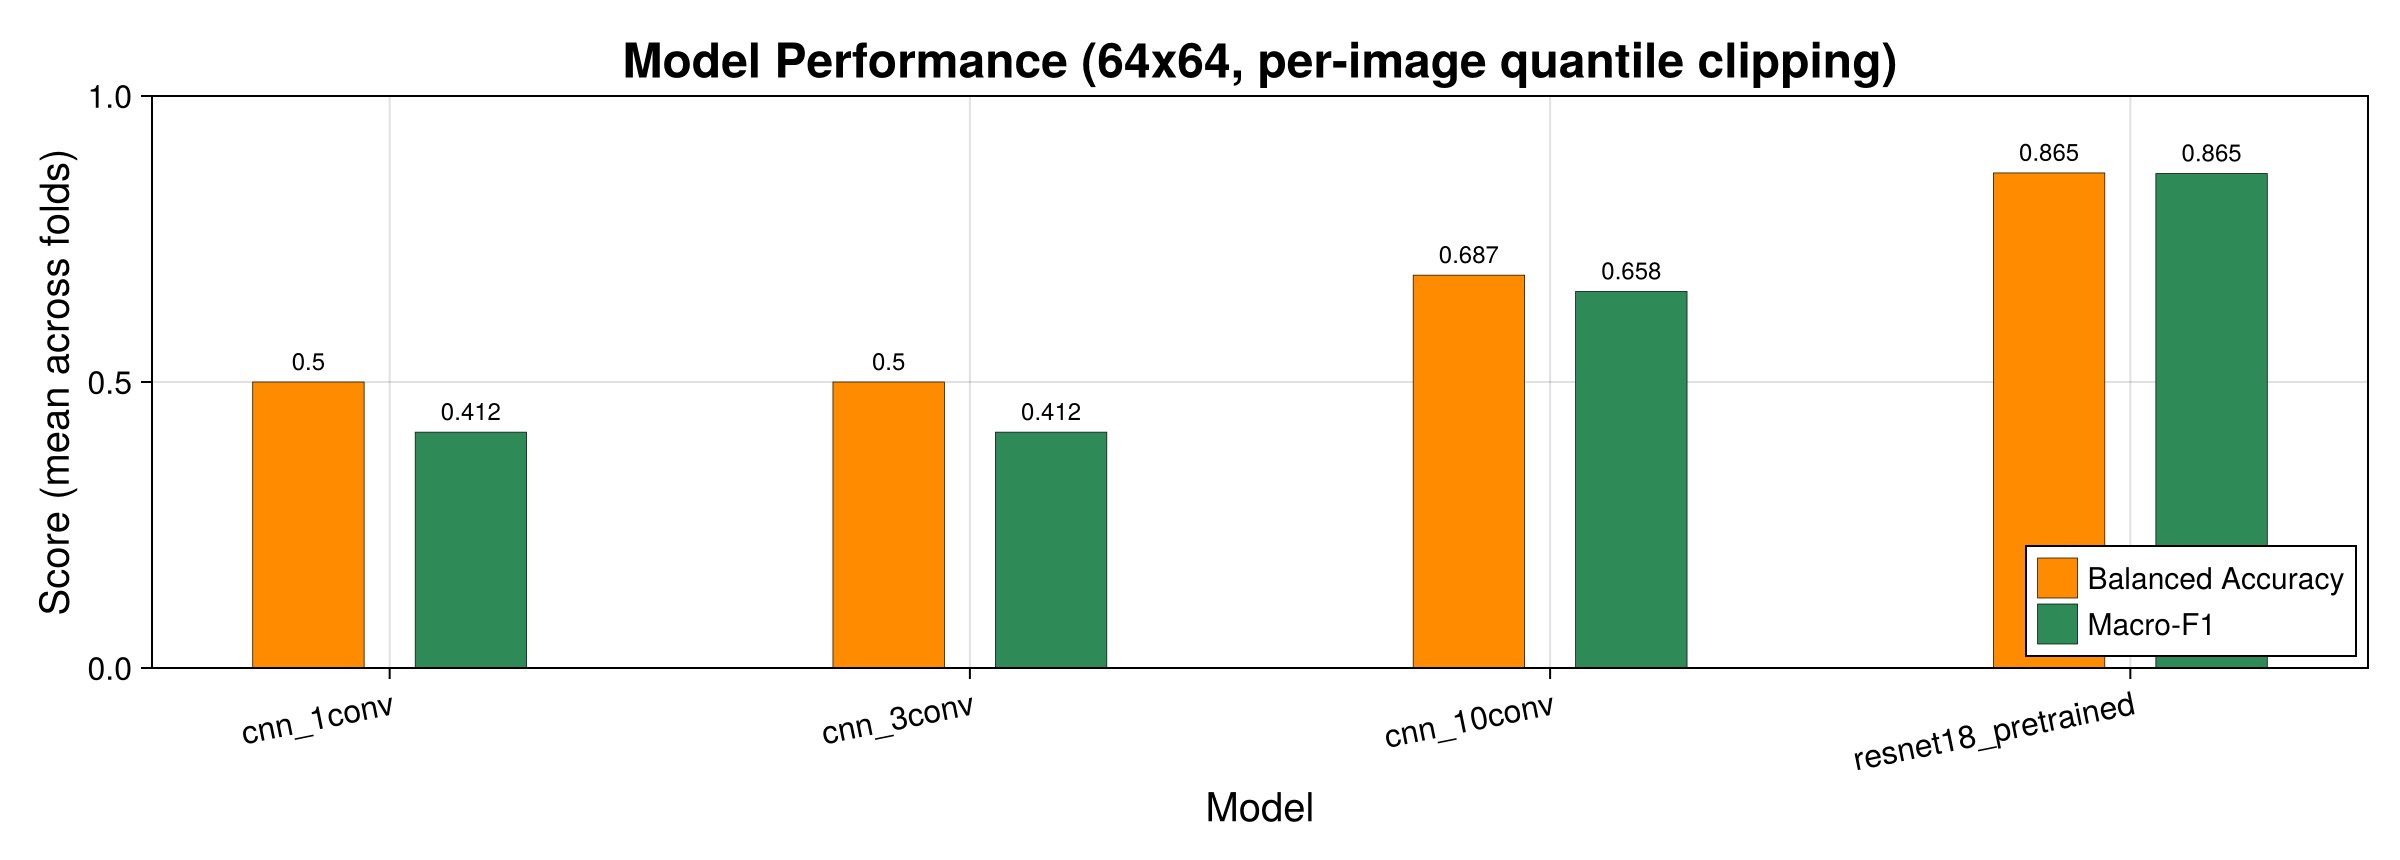

In [18]:
train_df_qclip, qclip_stats_df = apply_quantile_clip_01_99(train_df)

qclip_summary_stats_df = DataFrame(
    metric = [
        "mean_q01",
        "mean_q99",
        "mean_frac_low_clipped",
        "mean_frac_high_clipped",
    ],
    value = [
        mean(qclip_stats_df.q01),
        mean(qclip_stats_df.q99),
        mean(qclip_stats_df.frac_low_clipped),
        mean(qclip_stats_df.frac_high_clipped),
    ],
)

qclip_by_label_df = combine(
    groupby(qclip_stats_df, :binary_label),
    :q01 => mean => :mean_q01,
    :q99 => mean => :mean_q99,
    :frac_low_clipped => mean => :mean_frac_low_clipped,
    :frac_high_clipped => mean => :mean_frac_high_clipped,
)
sort!(qclip_by_label_df, :binary_label)

println("\nQuantile clipping summary (per-image clipping statistics):")
pretty_table(qclip_summary_stats_df; exp_table_kwargs...)

println("\nQuantile clipping summary by label:")
pretty_table(qclip_by_label_df; exp_table_kwargs...)

print_dataset_statistics(train_df_qclip; title = "Input dataset statistics: Quantile clipping (1% / 99%)")

qclip_run = run_cv_experiment_64(
    train_df_qclip;
    experiment_name = "64x64 | Per-image quantile clipping (1%/99%)",
    seed = 20260321,
)

qclip_single_value_df = qclip_run.single_value

fig_qclip_perf = plot_model_performance_bars(
    qclip_single_value_df;
    title = "Model Performance (64x64, per-image quantile clipping)",
)

fig_qclip_perf


## Experiment 2: Per-Image Scaling to [-1, 1]

This test rescales each 64x64 ERP matrix independently to a fixed range [-1, 1] after downscaling.



Min-max scaling summary (per-image statistics):
┌─────────────────┬───────────┐
│          metric │     value │
│          String │   Float64 │
├─────────────────┼───────────┤
│ mean_min_before │ -0.691237 │
│ mean_max_before │  0.689518 │
│  mean_min_after │      -1.0 │
│  mean_max_after │       1.0 │
└─────────────────┴───────────┘

Min-max scaling summary by label:
┌──────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┐
│ binary_label │ mean_min_before │ mean_max_before │ mean_min_after │ mean_max_after │
│        Int64 │         Float64 │         Float64 │        Float64 │        Float64 │
├──────────────┼─────────────────┼─────────────────┼────────────────┼────────────────┤
│            0 │       -0.673525 │        0.677174 │           -1.0 │            1.0 │
│            1 │       -0.732932 │        0.718578 │           -1.0 │            1.0 │
└──────────────┴─────────────────┴─────────────────┴────────────────┴────────────────┘

Input dataset stat

[ Info: cnn_1conv | fold 1 | epoch 1/10 | train_loss=0.69808
[ Info: cnn_1conv | fold 1 | epoch 2/10 | train_loss=0.6658
[ Info: cnn_1conv | fold 1 | epoch 3/10 | train_loss=0.64828
[ Info: cnn_1conv | fold 1 | epoch 4/10 | train_loss=0.63807
[ Info: cnn_1conv | fold 1 | epoch 5/10 | train_loss=0.62314
[ Info: cnn_1conv | fold 1 | epoch 6/10 | train_loss=0.61052
[ Info: cnn_1conv | fold 1 | epoch 7/10 | train_loss=0.59954
[ Info: cnn_1conv | fold 1 | epoch 8/10 | train_loss=0.59238
[ Info: cnn_1conv | fold 1 | epoch 9/10 | train_loss=0.59515
[ Info: cnn_1conv | fold 1 | epoch 10/10 | train_loss=0.66719
[ Info: cnn_1conv | fold 2 | epoch 1/10 | train_loss=0.66656
[ Info: cnn_1conv | fold 2 | epoch 2/10 | train_loss=0.64979
[ Info: cnn_1conv | fold 2 | epoch 3/10 | train_loss=0.664
[ Info: cnn_1conv | fold 2 | epoch 4/10 | train_loss=0.61569
[ Info: cnn_1conv | fold 2 | epoch 5/10 | train_loss=0.60997
[ Info: cnn_1conv | fold 2 | epoch 6/10 | train_loss=0.60234
[ Info: cnn_1conv | fold 2


----------------------------------------------------------------------------------------

[ Info: cnn_1conv | fold 5 | epoch 1/10 | train_loss=0.67467
[ Info: cnn_1conv | fold 5 | epoch 2/10 | train_loss=0.66151
[ Info: cnn_1conv | fold 5 | epoch 3/10 | train_loss=0.63695
[ Info: cnn_1conv | fold 5 | epoch 4/10 | train_loss=0.63248
[ Info: cnn_1conv | fold 5 | epoch 5/10 | train_loss=0.60559
[ Info: cnn_1conv | fold 5 | epoch 6/10 | train_loss=0.60585
[ Info: cnn_1conv | fold 5 | epoch 7/10 | train_loss=0.61223
[ Info: cnn_1conv | fold 5 | epoch 8/10 | train_loss=0.60919
[ Info: cnn_1conv | fold 5 | epoch 9/10 | train_loss=0.60565
[ Info: cnn_1conv | fold 5 | epoch 10/10 | train_loss=0.59205



Running model: cnn_3conv | experiment=64x64 | Per-image scaling to [-1, 1]
  input_type=gray | nepochs=10 | lr=0.001 | batchsize=64
----------------------------------------------------------------------------------------


...


Running model: resnet18_pretrained | experiment=64x64 | Per-image scaling to [-1, 1]
  input_type=rgb | nepochs=8 | lr=0.0003 | batchsize=32
----------------------------------------------------------------------------------------


[ Info: resnet18_pretrained | fold 1 | epoch 1/8 | train_loss=0.79037
[ Info: resnet18_pretrained | fold 1 | epoch 2/8 | train_loss=0.21621
[ Info: resnet18_pretrained | fold 1 | epoch 3/8 | train_loss=0.27277
[ Info: resnet18_pretrained | fold 1 | epoch 4/8 | train_loss=0.07238
[ Info: resnet18_pretrained | fold 1 | epoch 5/8 | train_loss=0.19132
[ Info: resnet18_pretrained | fold 1 | epoch 6/8 | train_loss=0.09837
[ Info: resnet18_pretrained | fold 1 | epoch 7/8 | train_loss=0.10526
[ Info: resnet18_pretrained | fold 1 | epoch 8/8 | train_loss=0.10744
[ Info: resnet18_pretrained | fold 2 | epoch 1/8 | train_loss=0.77625
[ Info: resnet18_pretrained | fold 2 | epoch 2/8 | train_loss=0.42266
[ Info: resnet18_pretrained | fold 2 | epoch 3/8 | train_loss=0.14049
[ Info: resnet18_pretrained | fold 2 | epoch 4/8 | train_loss=0.19538
[ Info: resnet18_pretrained | fold 2 | epoch 5/8 | train_loss=0.08707
[ Info: resnet18_pretrained | fold 2 | epoch 6/8 | train_loss=0.02791
[ Info: resnet18_pre


Fold-level performance:


[ Info: resnet18_pretrained | fold 5 | epoch 8/8 | train_loss=0.09104


┌─────────────────────┬───────┬─────────┬───────┬──────────┬───────────────────┬──────────┬──────────────┬─────────────┬──────────────┬──────────┬──────────────────────────┐
│          model_name │  fold │ n_train │ n_val │ accuracy │ balanced_accuracy │ macro_f1 │ train_time_s │  val_time_s │ total_time_s │ params_n │ pretrained_params_loaded │
│              String │ Int64 │   Int64 │ Int64 │  Float64 │           Float64 │  Float64 │      Float64 │     Float64 │      Float64 │    Int64 │                    Int64 │
├─────────────────────┼───────┼─────────┼───────┼──────────┼───────────────────┼──────────┼──────────────┼─────────────┼──────────────┼──────────┼──────────────────────────┤
│          cnn_10conv │     1 │     513 │   131 │ 0.709924 │               0.5 │ 0.415179 │      3.17146 │   0.0269624 │      3.19842 │    84258 │                        0 │
│          cnn_10conv │     2 │     513 │   131 │ 0.458015 │          0.594935 │ 0.454839 │      3.17115 │   0.0267728 │      3.19

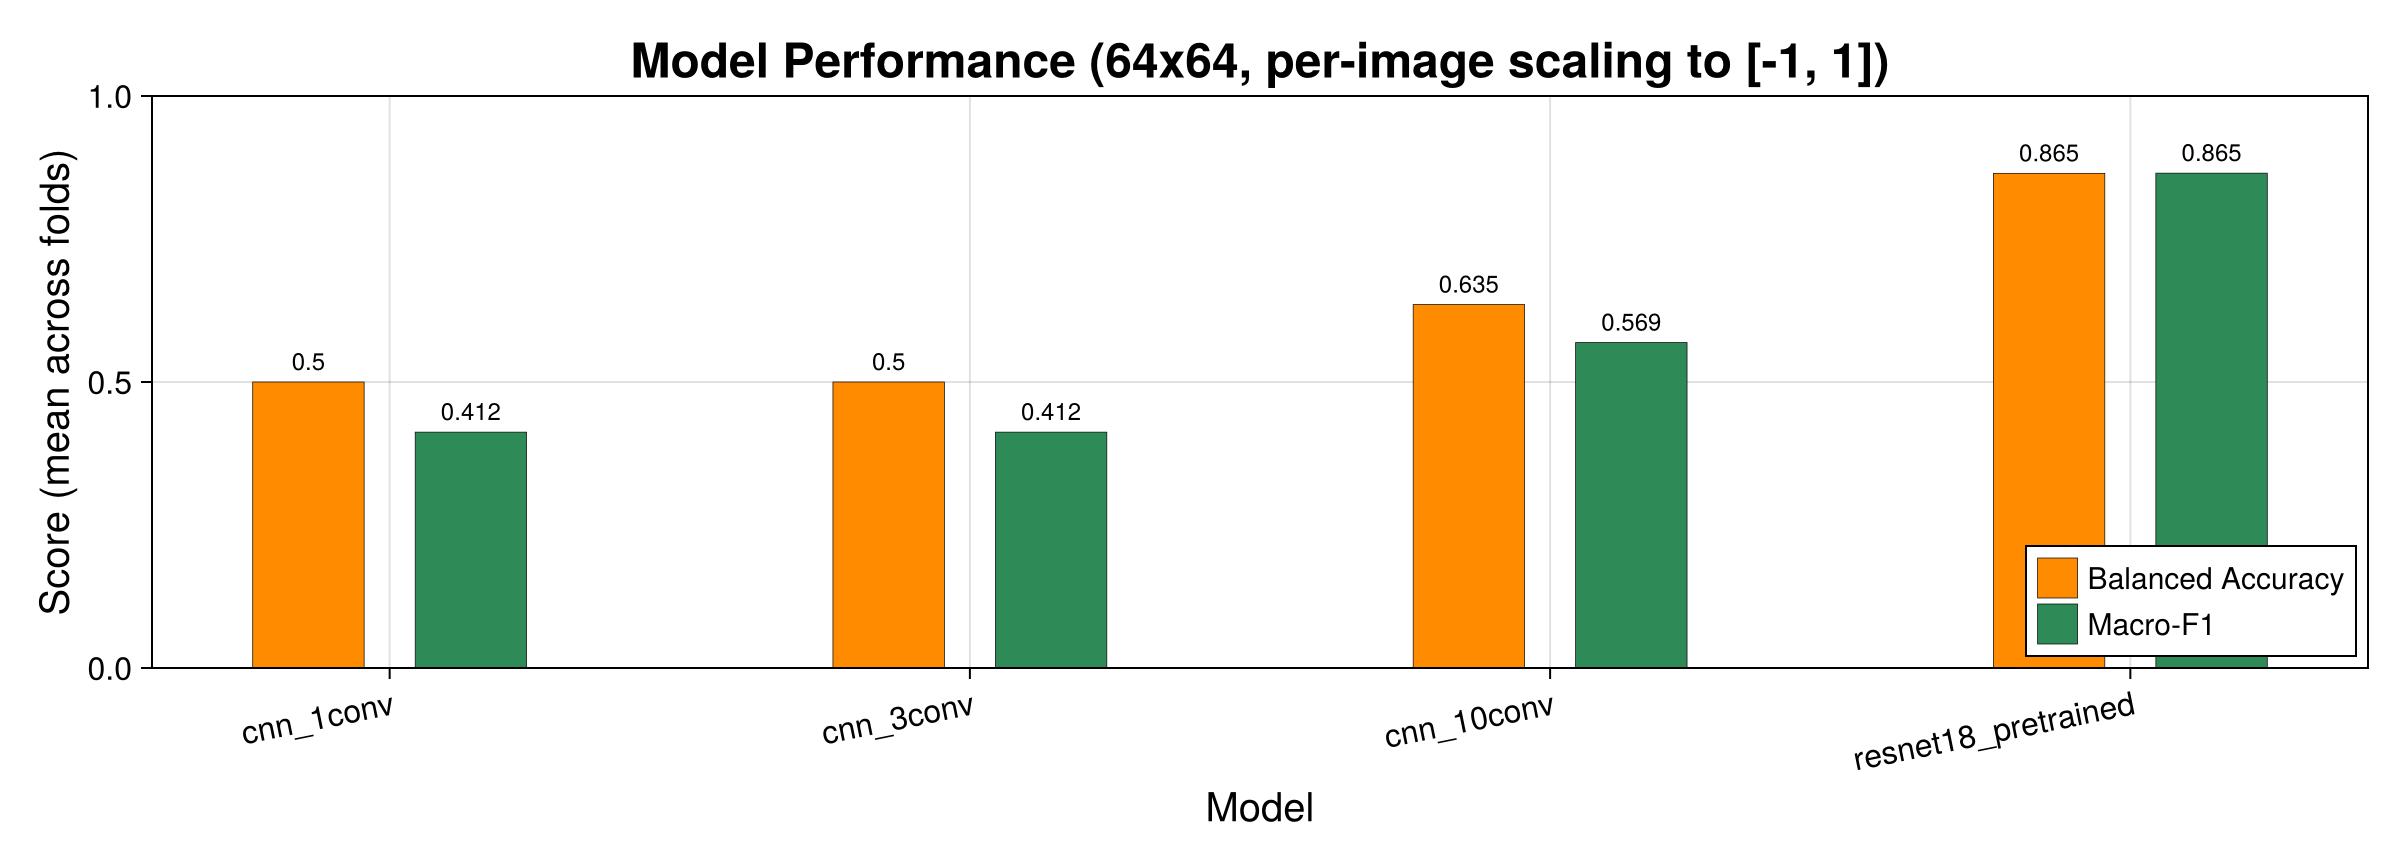

In [19]:
train_df_minmax, minmax_stats_df = apply_minmax_minus1_1(train_df)

minmax_summary_stats_df = DataFrame(
    metric = [
        "mean_min_before",
        "mean_max_before",
        "mean_min_after",
        "mean_max_after",
    ],
    value = [
        mean(minmax_stats_df.min_before),
        mean(minmax_stats_df.max_before),
        mean(minmax_stats_df.min_after),
        mean(minmax_stats_df.max_after),
    ],
)

minmax_by_label_df = combine(
    groupby(minmax_stats_df, :binary_label),
    :min_before => mean => :mean_min_before,
    :max_before => mean => :mean_max_before,
    :min_after => mean => :mean_min_after,
    :max_after => mean => :mean_max_after,
)
sort!(minmax_by_label_df, :binary_label)

println("\nMin-max scaling summary (per-image statistics):")
pretty_table(minmax_summary_stats_df; exp_table_kwargs...)

println("\nMin-max scaling summary by label:")
pretty_table(minmax_by_label_df; exp_table_kwargs...)

print_dataset_statistics(train_df_minmax; title = "Input dataset statistics: Per-image scaling to [-1, 1]")

minmax_run = run_cv_experiment_64(
    train_df_minmax;
    experiment_name = "64x64 | Per-image scaling to [-1, 1]",
    seed = 20260322,
)

minmax_single_value_df = minmax_run.single_value

fig_minmax_perf = plot_model_performance_bars(
    minmax_single_value_df;
    title = "Model Performance (64x64, per-image scaling to [-1, 1])",
)

fig_minmax_perf


## Experiment 3: Balanced Class Counts (Drop No-Class Samples)

This test keeps all class samples and removes no-class samples until class and no-class counts are equal.
The no-class keep-set is sampled randomly with a round-robin strategy over `sort_var` to keep the distribution as even as possible.



No-class sampling summary by sort variable (before / kept / dropped):
┌──────────────────┬─────────────────┬───────────────┬──────────────────┐
│         sort_var │ no_class_before │ no_class_kept │ no_class_dropped │
│           String │           Int64 │         Int64 │            Int64 │
├──────────────────┼─────────────────┼───────────────┼──────────────────┤
│         duration │              47 │            32 │               15 │
│     fix_avgpos_x │              84 │            32 │               52 │
│ fix_avgpupilsize │              84 │            32 │               52 │
│         fix_type │              82 │            32 │               50 │
│          latency │              82 │            32 │               50 │
│    sac_amplitude │              73 │            32 │               41 │
└──────────────────┴─────────────────┴───────────────┴──────────────────┘

Final class distribution after no-class downsampling:
┌──────────────┬───────┐
│ binary_label │ count │
│        I

[ Info: cnn_1conv | fold 1 | epoch 1/10 | train_loss=0.69338
[ Info: cnn_1conv | fold 1 | epoch 2/10 | train_loss=0.69332
[ Info: cnn_1conv | fold 1 | epoch 3/10 | train_loss=0.69301
[ Info: cnn_1conv | fold 1 | epoch 4/10 | train_loss=0.69256
[ Info: cnn_1conv | fold 1 | epoch 5/10 | train_loss=0.69249
[ Info: cnn_1conv | fold 1 | epoch 6/10 | train_loss=0.69261
[ Info: cnn_1conv | fold 1 | epoch 7/10 | train_loss=0.69226
[ Info: cnn_1conv | fold 1 | epoch 8/10 | train_loss=0.69219
[ Info: cnn_1conv | fold 1 | epoch 9/10 | train_loss=0.69195
[ Info: cnn_1conv | fold 1 | epoch 10/10 | train_loss=0.692
[ Info: cnn_1conv | fold 2 | epoch 1/10 | train_loss=0.69232
[ Info: cnn_1conv | fold 2 | epoch 2/10 | train_loss=0.69252
[ Info: cnn_1conv | fold 2 | epoch 3/10 | train_loss=0.69222
[ Info: cnn_1conv | fold 2 | epoch 4/10 | train_loss=0.69186
[ Info: cnn_1conv | fold 2 | epoch 5/10 | train_loss=0.69171
[ Info: cnn_1conv | fold 2 | epoch 6/10 | train_loss=0.69151
[ Info: cnn_1conv | fold 


----------------------------------------------------------------------------------------

[ Info: cnn_1conv | fold 5 | epoch 1/10 | train_loss=0.69321
[ Info: cnn_1conv | fold 5 | epoch 2/10 | train_loss=0.69303
[ Info: cnn_1conv | fold 5 | epoch 3/10 | train_loss=0.69264
[ Info: cnn_1conv | fold 5 | epoch 4/10 | train_loss=0.69254
[ Info: cnn_1conv | fold 5 | epoch 5/10 | train_loss=0.69228
[ Info: cnn_1conv | fold 5 | epoch 6/10 | train_loss=0.69209
[ Info: cnn_1conv | fold 5 | epoch 7/10 | train_loss=0.69184
[ Info: cnn_1conv | fold 5 | epoch 8/10 | train_loss=0.6921
[ Info: cnn_1conv | fold 5 | epoch 9/10 | train_loss=0.69161
[ Info: cnn_1conv | fold 5 | epoch 10/10 | train_loss=0.69141



Running model: cnn_3conv | experiment=64x64 | Balanced class counts (no-class downsampling)
  input_type=gray | nepochs=10 | lr=0.001 | batchsize=64
----------------------------------------------------------------------------------------


...


Running model: cnn_10conv | experiment=64x64 | Balanced class counts (no-class downsampling)
  input_type=gray | nepochs=12 | lr=0.0008 | batchsize=64
----------------------------------------------------------------------------------------


[ Info: cnn_10conv | fold 1 | epoch 1/12 | train_loss=0.77128
[ Info: cnn_10conv | fold 1 | epoch 2/12 | train_loss=0.64068
[ Info: cnn_10conv | fold 1 | epoch 3/12 | train_loss=0.59204
[ Info: cnn_10conv | fold 1 | epoch 4/12 | train_loss=0.577
[ Info: cnn_10conv | fold 1 | epoch 5/12 | train_loss=0.53842
[ Info: cnn_10conv | fold 1 | epoch 6/12 | train_loss=0.50995
[ Info: cnn_10conv | fold 1 | epoch 7/12 | train_loss=0.48646
[ Info: cnn_10conv | fold 1 | epoch 8/12 | train_loss=0.43207
[ Info: cnn_10conv | fold 1 | epoch 9/12 | train_loss=0.39686
[ Info: cnn_10conv | fold 1 | epoch 10/12 | train_loss=0.34707
[ Info: cnn_10conv | fold 1 | epoch 11/12 | train_loss=0.34113
[ Info: cnn_10conv | fold 1 | epoch 12/12 | train_loss=0.31359
[ Info: cnn_10conv | fold 2 | epoch 1/12 | train_loss=0.67329
[ Info: cnn_10conv | fold 2 | epoch 2/12 | train_loss=0.59641
[ Info: cnn_10conv | fold 2 | epoch 3/12 | train_loss=0.54847
[ Info: cnn_10conv | fold 2 | epoch 4/12 | train_loss=0.4815
[ Info: 


----------------------------------------------------------------------------------------
Running model: resnet18_pretrained | experiment=64x64 | Balanced class counts (no-class downsampling)
  input_type=rgb | nepochs=8 | lr=0.0003 | batchsize=32
----------------------------------------------------------------------------------------


[ Info: resnet18_pretrained | fold 1 | epoch 1/8 | train_loss=0.83278
[ Info: resnet18_pretrained | fold 1 | epoch 2/8 | train_loss=0.42073
[ Info: resnet18_pretrained | fold 1 | epoch 3/8 | train_loss=0.08882
[ Info: resnet18_pretrained | fold 1 | epoch 4/8 | train_loss=0.05448
[ Info: resnet18_pretrained | fold 1 | epoch 5/8 | train_loss=0.00666
[ Info: resnet18_pretrained | fold 1 | epoch 6/8 | train_loss=0.01281
[ Info: resnet18_pretrained | fold 1 | epoch 7/8 | train_loss=0.02501
[ Info: resnet18_pretrained | fold 1 | epoch 8/8 | train_loss=0.03402
[ Info: resnet18_pretrained | fold 2 | epoch 1/8 | train_loss=0.86363
[ Info: resnet18_pretrained | fold 2 | epoch 2/8 | train_loss=0.35397
[ Info: resnet18_pretrained | fold 2 | epoch 3/8 | train_loss=0.11566
[ Info: resnet18_pretrained | fold 2 | epoch 4/8 | train_loss=0.09543
[ Info: resnet18_pretrained | fold 2 | epoch 5/8 | train_loss=0.02592
[ Info: resnet18_pretrained | fold 2 | epoch 6/8 | train_loss=0.09259
[ Info: resnet18_pre


Fold-level performance:
┌─────────────────────┬───────┬─────────┬───────┬──────────┬───────────────────┬──────────┬──────────────┬─────────────┬──────────────┬──────────┬──────────────────────────┐
│          model_name │  fold │ n_train │ n_val │ accuracy │ balanced_accuracy │ macro_f1 │ train_time_s │  val_time_s │ total_time_s │ params_n │ pretrained_params_loaded │
│              String │ Int64 │   Int64 │ Int64 │  Float64 │           Float64 │  Float64 │      Float64 │     Float64 │      Float64 │    Int64 │                    Int64 │
├─────────────────────┼───────┼─────────┼───────┼──────────┼───────────────────┼──────────┼──────────────┼─────────────┼──────────────┼──────────┼──────────────────────────┤
│          cnn_10conv │     1 │     304 │    80 │    0.625 │          0.606516 │ 0.553571 │      2.02118 │   0.0864623 │      2.10764 │    84258 │                        0 │
│          cnn_10conv │     2 │     304 │    80 │   0.6375 │          0.618421 │ 0.563171 │      1.84809 

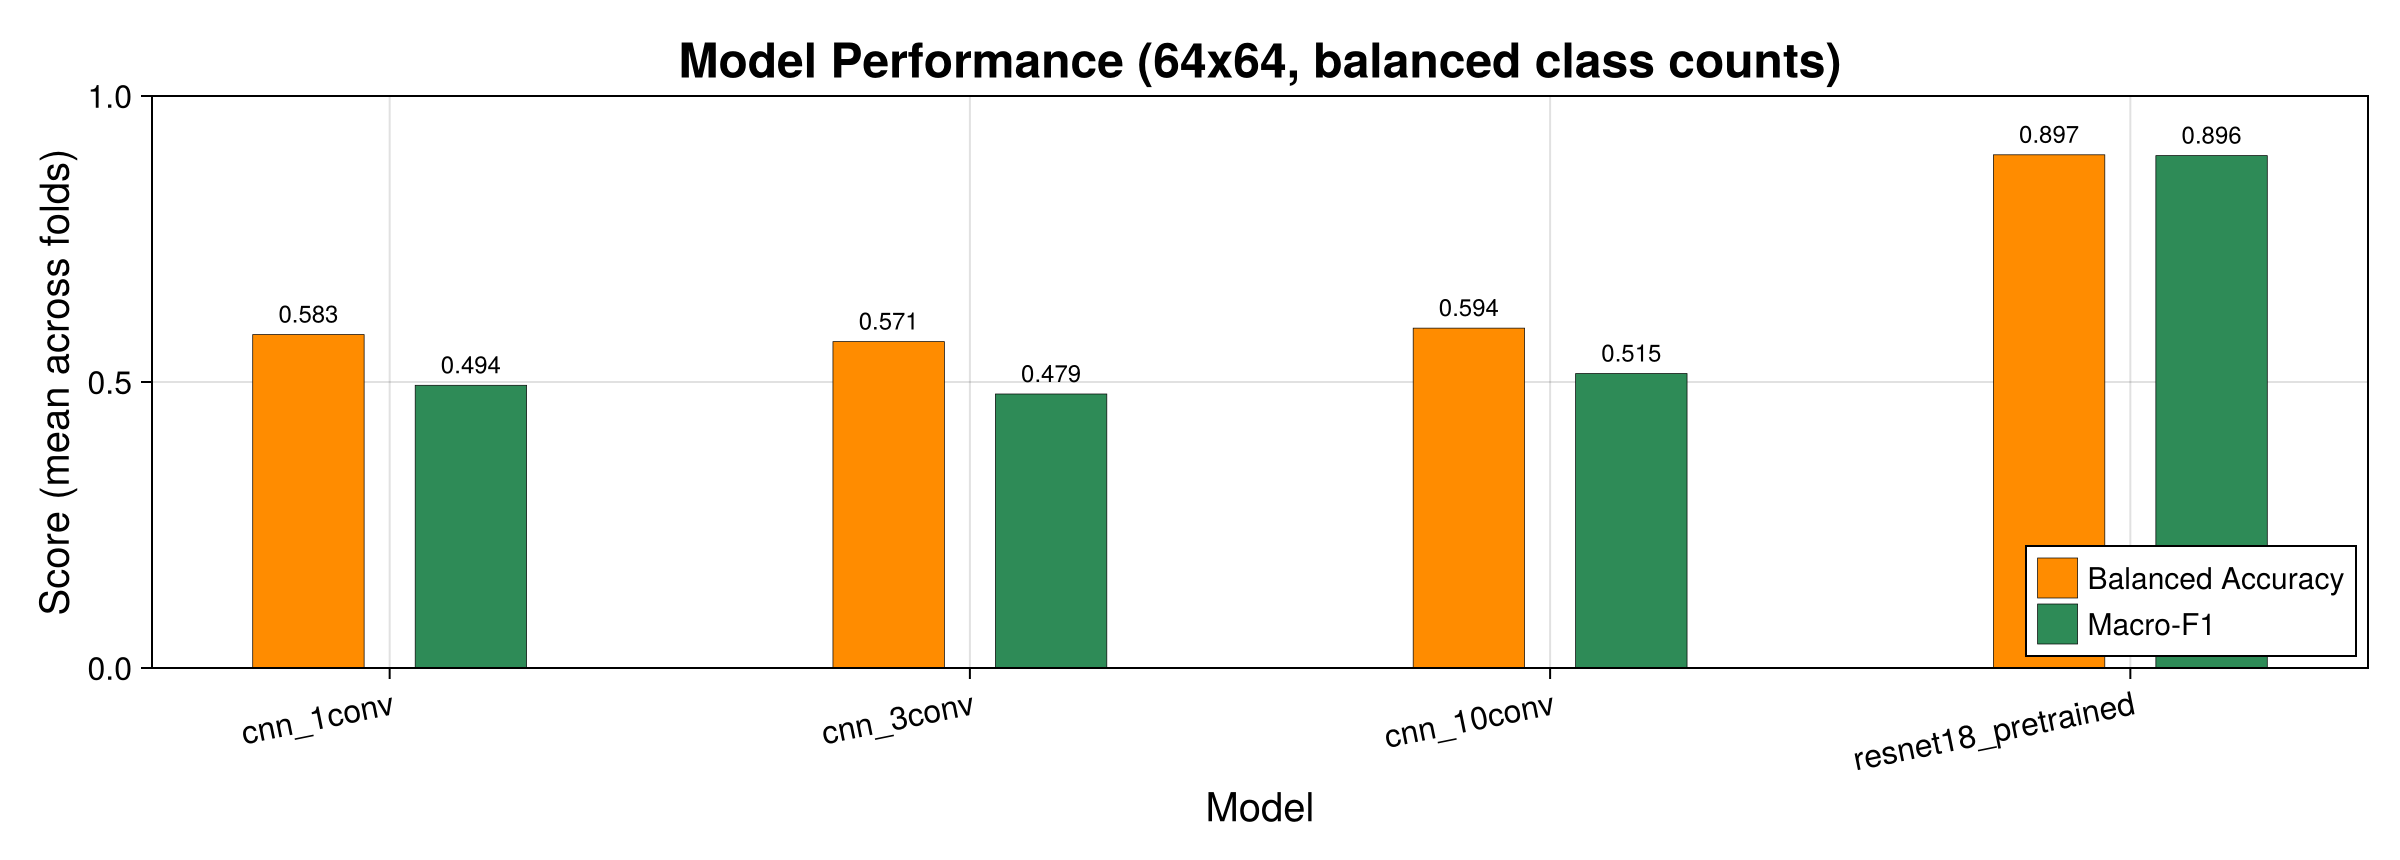

In [20]:
train_df_balanced, no_class_keep_stats_df = build_class_balanced_no_class_subset(train_df; seed = 20260323)

class_balance_df = combine(groupby(train_df_balanced, :binary_label), nrow => :count)
sort!(class_balance_df, :binary_label)

println("\nNo-class sampling summary by sort variable (before / kept / dropped):")
pretty_table(no_class_keep_stats_df; exp_table_kwargs...)

println("\nFinal class distribution after no-class downsampling:")
pretty_table(class_balance_df; exp_table_kwargs...)

print_dataset_statistics(train_df_balanced; title = "Input dataset statistics: Balanced class counts")

balanced_run = run_cv_experiment_64(
    train_df_balanced;
    experiment_name = "64x64 | Balanced class counts (no-class downsampling)",
    seed = 20260323,
)

balanced_single_value_df = balanced_run.single_value

fig_balanced_perf = plot_model_performance_bars(
    balanced_single_value_df;
    title = "Model Performance (64x64, balanced class counts)",
)

fig_balanced_perf


## 64x64 Overall Comparison Across Processing Steps

This section combines all 64x64 runs to compare how each processing step changes model performance.



Overall 64x64 comparison (per model, per processing step):
┌─────────────────────┬───────────────────────────┬───────────────────┬──────────┬────────────────────────────┬────────────────────────────┐
│          model_name │           processing_step │ balanced_accuracy │ macro_f1 │ delta_balanced_vs_baseline │ delta_macro_f1_vs_baseline │
│              String │                    String │           Float64 │  Float64 │                    Float64 │                    Float64 │
├─────────────────────┼───────────────────────────┼───────────────────┼──────────┼────────────────────────────┼────────────────────────────┤
│           cnn_1conv │     Baseline (mod4 split) │               0.5 │ 0.412358 │                        0.0 │                        0.0 │
│           cnn_1conv │    Per-image q01/q99 clip │               0.5 │ 0.412358 │                        0.0 │                        0.0 │
│           cnn_1conv │ Per-image scale to [-1,1] │               0.5 │ 0.412358 │            

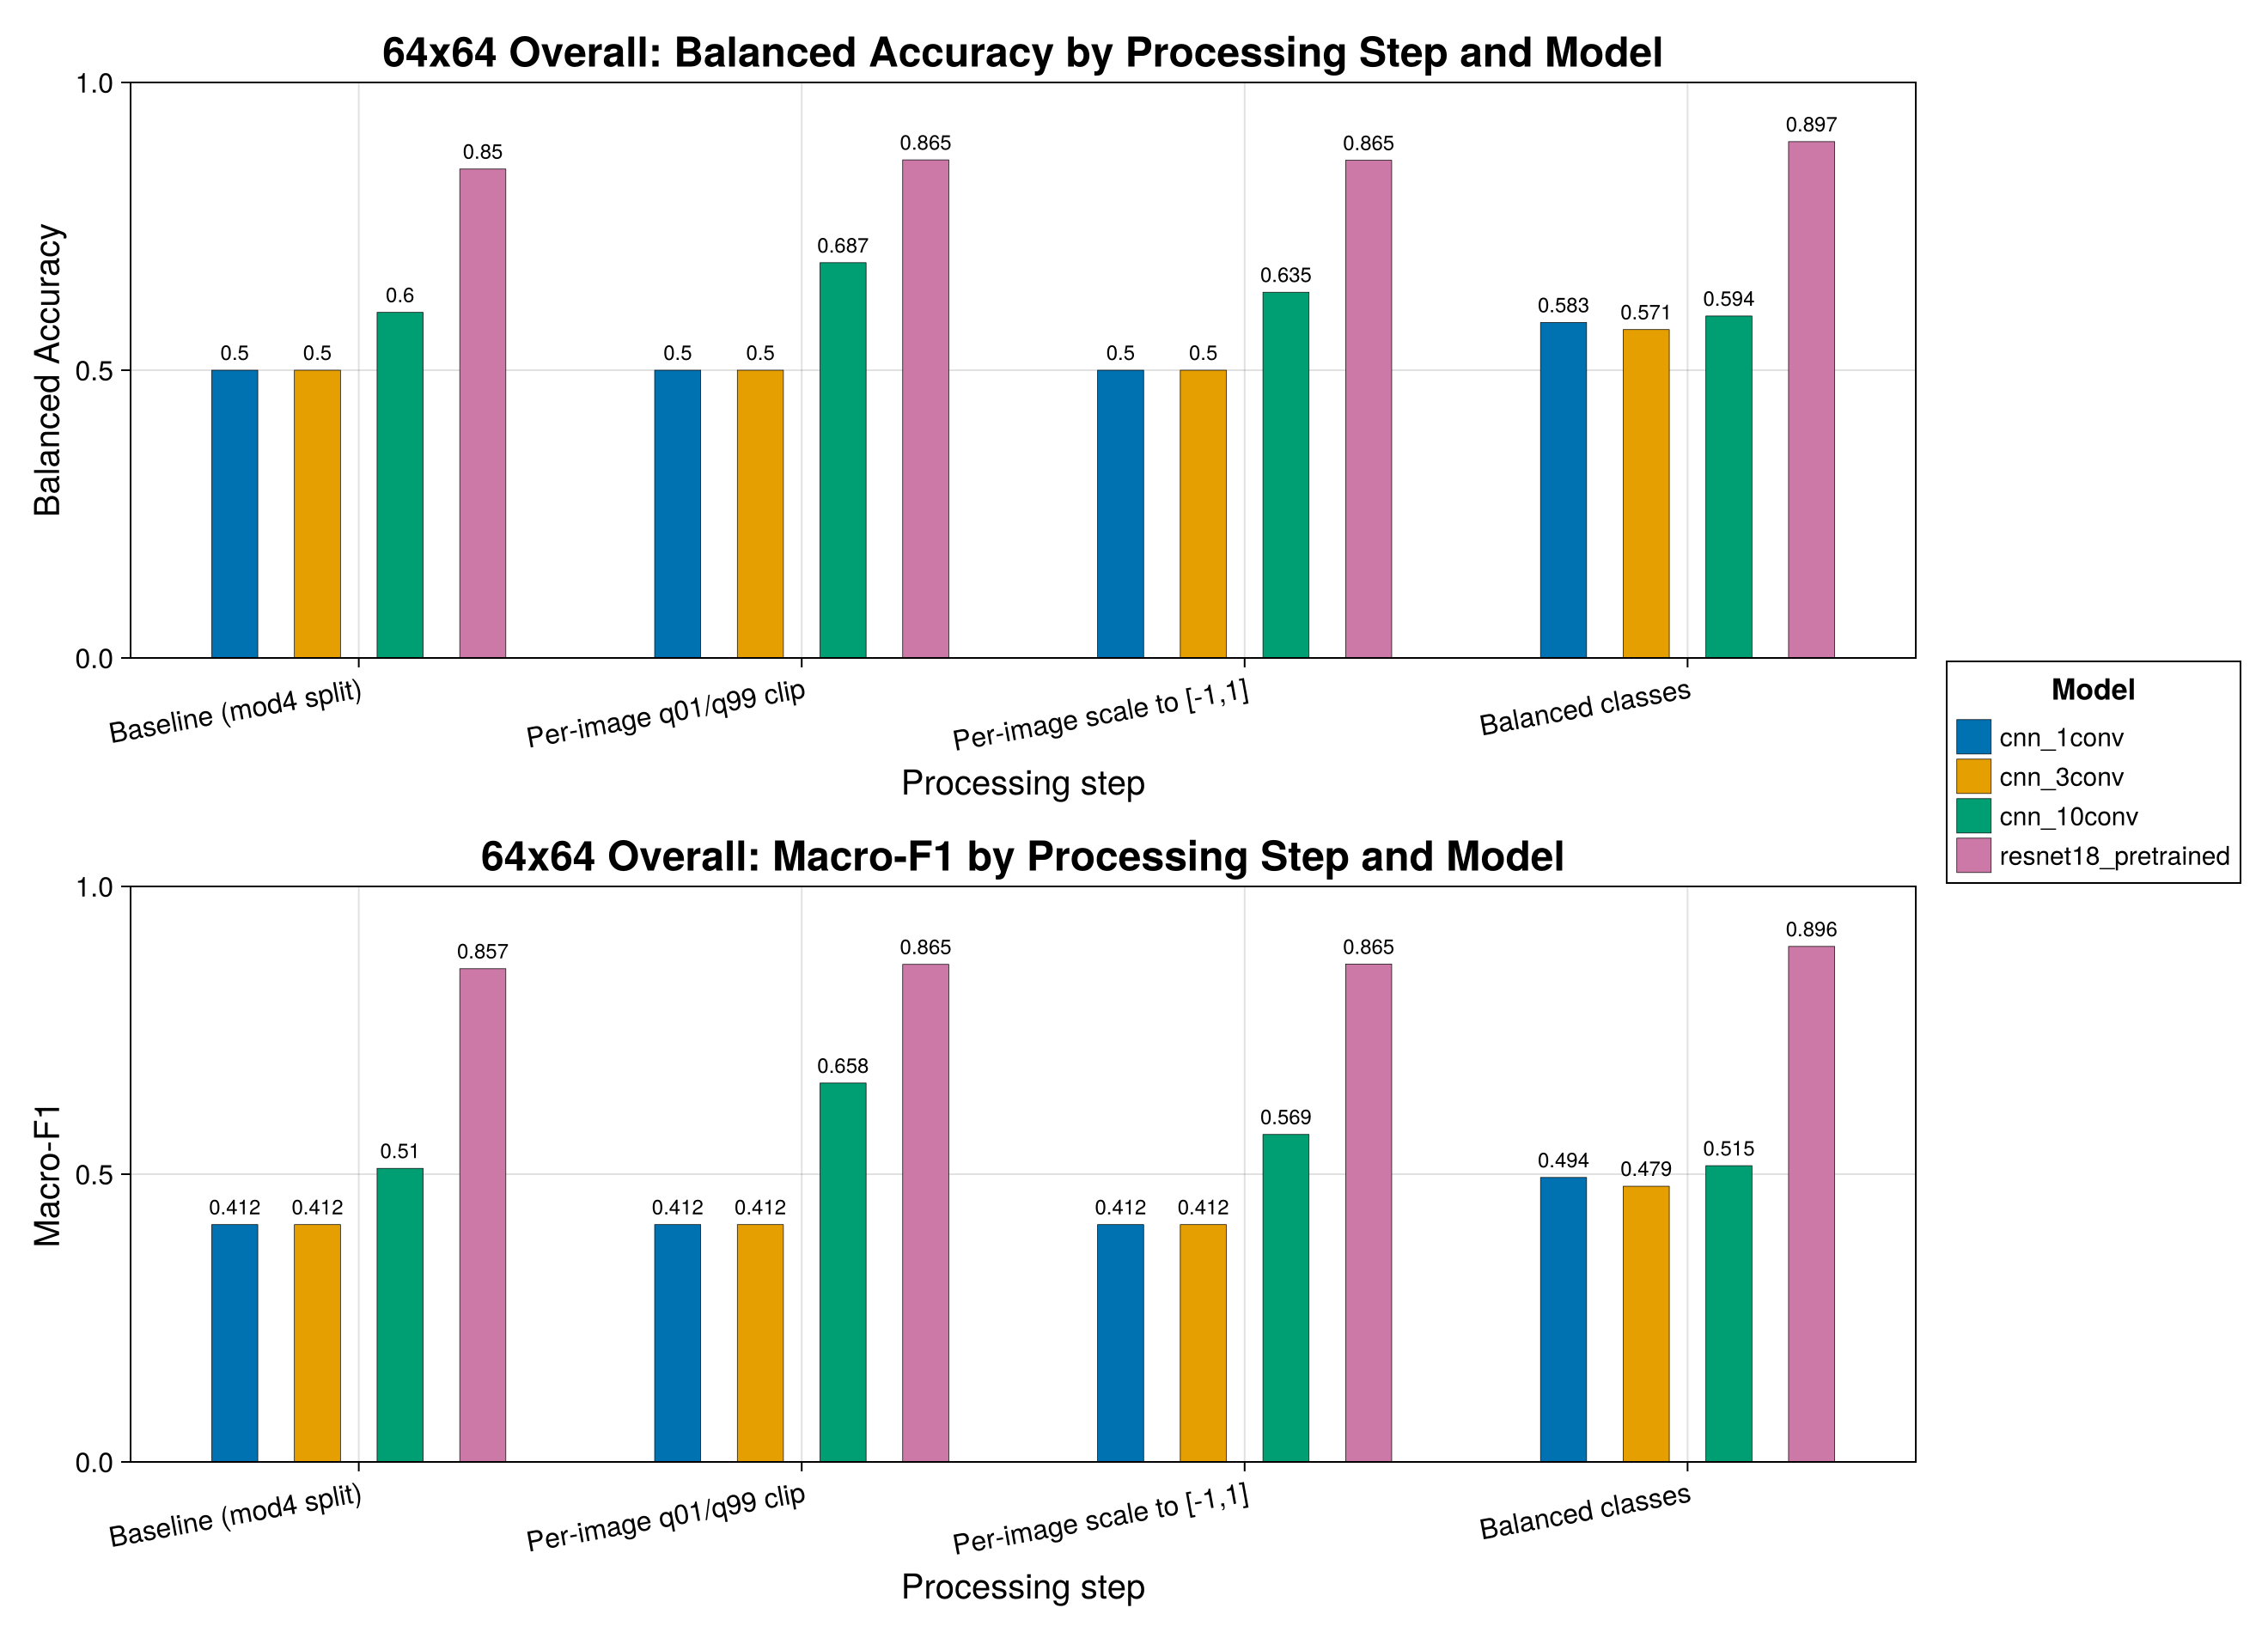

In [21]:
@assert @isdefined(qclip_single_value_df) "Run cell-020 first."
@assert @isdefined(minmax_single_value_df) "Run cell-022 first."
@assert @isdefined(balanced_single_value_df) "Run cell-024 first."

baseline_single_value_local = if @isdefined(single_value_summary_df)
    single_value_summary_df[:, [:model_name, :balanced_accuracy, :macro_f1]]
elseif @isdefined(summary_df)
    tmp = summary_df[:, [:model_name, :balanced_accuracy_mean, :macro_f1_mean]]
    rename!(tmp, :balanced_accuracy_mean => :balanced_accuracy, :macro_f1_mean => :macro_f1)
    tmp
elseif @isdefined(cv_results_df)
    combine(
        groupby(cv_results_df, :model_name),
        :balanced_accuracy => mean => :balanced_accuracy,
        :macro_f1 => mean => :macro_f1,
    )
else
    error("No baseline 64x64 summary found. Run earlier baseline CV cells first.")
end

step_sources = [
    (step_key = "baseline", step_label = "Baseline (mod4 split)", df = baseline_single_value_local),
    (step_key = "qclip", step_label = "Per-image q01/q99 clip", df = qclip_single_value_df),
    (step_key = "minmax", step_label = "Per-image scale to [-1,1]", df = minmax_single_value_df),
    (step_key = "balanced", step_label = "Balanced classes", df = balanced_single_value_df),
]

overview_rows = DataFrame[]
for (step_idx, step) in enumerate(step_sources)
    step_df = copy(step.df[:, [:model_name, :balanced_accuracy, :macro_f1]])
    step_df.processing_step = fill(step.step_label, nrow(step_df))
    step_df.processing_step_key = fill(step.step_key, nrow(step_df))
    step_df.step_order = fill(step_idx, nrow(step_df))
    push!(overview_rows, step_df)
end

overview_64_df = vcat(overview_rows...)
overview_64_df = reorder_models_for_plots(overview_64_df)

model_levels = ordered_model_names_present(String.(overview_64_df.model_name))
model_rank = Dict(m => i for (i, m) in enumerate(model_levels))
overview_64_df.model_order = [model_rank[String(m)] for m in overview_64_df.model_name]
sort!(overview_64_df, [:model_order, :step_order])

baseline_lookup = Dict(
    String(r.model_name) => (balanced = Float64(r.balanced_accuracy), macrof1 = Float64(r.macro_f1))
    for r in eachrow(baseline_single_value_local)
)

overview_64_df.delta_balanced_vs_baseline = [
    Float64(r.balanced_accuracy) - baseline_lookup[String(r.model_name)].balanced
    for r in eachrow(overview_64_df)
]
overview_64_df.delta_macro_f1_vs_baseline = [
    Float64(r.macro_f1) - baseline_lookup[String(r.model_name)].macrof1
    for r in eachrow(overview_64_df)
]

println("\nOverall 64x64 comparison (per model, per processing step):")
pretty_table(
    overview_64_df[:, [
        :model_name,
        :processing_step,
        :balanced_accuracy,
        :macro_f1,
        :delta_balanced_vs_baseline,
        :delta_macro_f1_vs_baseline,
    ]];
    exp_table_kwargs...,
)

overview_balanced_wide = unstack(
    overview_64_df[:, [:processing_step, :model_name, :balanced_accuracy]],
    :model_name,
    :balanced_accuracy,
)
overview_macro_wide = unstack(
    overview_64_df[:, [:processing_step, :model_name, :macro_f1]],
    :model_name,
    :macro_f1,
)

ordered_cols = Symbol.(vcat(["processing_step"], model_levels))
overview_balanced_wide = overview_balanced_wide[:, ordered_cols]
overview_macro_wide = overview_macro_wide[:, ordered_cols]

println("\nBalanced accuracy overview (rows=processing steps, cols=models):")
pretty_table(overview_balanced_wide; exp_table_kwargs...)

println("\nMacro-F1 overview (rows=processing steps, cols=models):")
pretty_table(overview_macro_wide; exp_table_kwargs...)

best_by_model_df = combine(
    groupby(overview_64_df, :model_name),
    :balanced_accuracy => maximum => :best_balanced_accuracy,
    :macro_f1 => maximum => :best_macro_f1,
)
sort!(best_by_model_df, [:model_name])
println("\nBest observed value per model across all shown 64x64 processing steps:")
pretty_table(best_by_model_df; exp_table_kwargs...)

step_labels = [s.step_label for s in step_sources]
step_to_x = Dict(step_labels[i] => i for i in eachindex(step_labels))

n_models = length(model_levels)
offset_span = 0.56
model_offsets = n_models <= 1 ? [0.0] : collect(range(-offset_span / 2, offset_span / 2, length = n_models))
bar_width = 0.13
colors = Makie.wong_colors()

fig_overview = Figure(size = (1320, 950))

ax_bal = Axis(
    fig_overview[1, 1],
    title = "64x64 Overall: Balanced Accuracy by Processing Step and Model",
    xlabel = "Processing step",
    ylabel = "Balanced Accuracy",
    xticks = (collect(1:length(step_labels)), step_labels),
    xticklabelrotation = 0.18,
    titlesize = 24,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 16,
    yticklabelsize = 16,
)

ax_f1 = Axis(
    fig_overview[2, 1],
    title = "64x64 Overall: Macro-F1 by Processing Step and Model",
    xlabel = "Processing step",
    ylabel = "Macro-F1",
    xticks = (collect(1:length(step_labels)), step_labels),
    xticklabelrotation = 0.18,
    titlesize = 24,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 16,
    yticklabelsize = 16,
)

for (j, model_name) in enumerate(model_levels)
    idx = findall(==(model_name), String.(overview_64_df.model_name))
    isempty(idx) && continue

    step_x = [step_to_x[String(overview_64_df.processing_step[i])] for i in idx]
    xj = step_x .+ model_offsets[j]

    y_bal = Float64.(overview_64_df.balanced_accuracy[idx])
    y_f1 = Float64.(overview_64_df.macro_f1[idx])

    barplot!(
        ax_bal,
        xj,
        y_bal;
        width = bar_width,
        color = colors[((j - 1) % length(colors)) + 1],
        strokecolor = :black,
        strokewidth = 0.35,
        label = model_name,
    )

    barplot!(
        ax_f1,
        xj,
        y_f1;
        width = bar_width,
        color = colors[((j - 1) % length(colors)) + 1],
        strokecolor = :black,
        strokewidth = 0.35,
        label = model_name,
    )

    text!(ax_bal, xj, y_bal .+ 0.010, text = string.(round.(y_bal, digits = 3)), align = (:center, :bottom), fontsize = 12)
    text!(ax_f1, xj, y_f1 .+ 0.010, text = string.(round.(y_f1, digits = 3)), align = (:center, :bottom), fontsize = 12)
end

ylims!(ax_bal, 0, 1)
ylims!(ax_f1, 0, 1)

Legend(fig_overview[1:2, 2], ax_bal, "Model"; labelsize = 15, titlesize = 17)

fig_overview


# Additional 2-Channel Filter Experiment (64x64)

This section adds a second input channel that contains a filtered ERP image.
For each sample, channel 1 is the normal ERP pipeline and channel 2 is the same sample with an additional filter after z-score and before low-pass.


In [22]:
@assert @isdefined(erps) && @isdefined(events) && @isdefined(labels_df) "Run the baseline data-loading cells first."

function print_two_channel_pipeline_overview(filter_name::String)
    println()
    println("=== 2-Channel Filter Experiment: Pipeline Overview ===")
    println("Aktueller Filter: ", filter_name)
    println()
    println("Kanal 1 (normal ERP image):")
    println("  raw trials")
    println("  → sort by sort_variable")
    println("  → augment: modulo-split in 4 subsets (gleich für beide Klassen)")
    println("  → pro Subset: zscore per timepoint (across trials)")
    println("  → low-pass filter (σ=75.0, kernel=21×21, border=reflect)")
    println("  → resize to 64×64")
    println()
    println("Kanal 2 (experimental filter channel):")
    println("  raw trials")
    println("  → sort by sort_variable")
    println("  → augment: modulo-split in 4 subsets (identische Subsets wie Kanal 1!)")
    println("  → pro Subset: zscore per timepoint (across trials)")
    println("  → experimentaler Filter anwenden (aktuell: ", filter_name, ")")
    println("  → low-pass filter (σ=75.0, kernel=21×21, border=reflect)")
    println("  → resize to 64×64")
    println()
    println("Beide Kanäle werden als (64, 64, 2, N) Tensor zusammengefügt.")
    println("Der experimentale Filter wird NACH dem zscore und VOR dem low-pass angewendet.")
end

function preprocess_erp_subset_two_channel(data_time_trials::AbstractMatrix, events_trials::DataFrame, sort_col::Symbol;
    filter_fn::Function,
    target_size::Tuple{Int, Int} = TARGET_SIZE,
    low_pass_sigma::Float32 = LOWPASS_SIGMA,
    lowpass_kernel_size::Tuple{Int, Int} = LOWPASS_KERNEL_SIZE,
    filter_border::String = FILTER_BORDER)

    @assert size(data_time_trials, 2) == nrow(events_trials) "trial count mismatch between matrix and events"
    @assert sort_col in propertynames(events_trials) "sort column not found: $(sort_col)"

    # 1) Sort by sort_variable.
    sortvals = sortvalues_from(events_trials, sort_col)
    order = sortperm(sortvals)
    data_sorted = data_time_trials[:, order]

    # 2) z-score per timepoint over trials.
    data_z = zscore_timepoints(data_sorted)
    img_trials_time = Float32.(permutedims(data_z, (2, 1)))

    kernel = gaussian_kernel(low_pass_sigma, size(img_trials_time), target_size, lowpass_kernel_size)

    # Channel 1: zscore -> lowpass -> resize.
    normal_lowpass = Float32.(imfilter(img_trials_time, kernel, filter_border))
    img_normal = Float32.(imresize(normal_lowpass, target_size))

    # Channel 2: zscore -> filter -> lowpass -> resize.
    filtered = Float32.(filter_fn(Float32.(img_trials_time)))
    filtered_lowpass = Float32.(imfilter(filtered, kernel, filter_border))
    img_filtered = Float32.(imresize(filtered_lowpass, target_size))

    return img_normal, img_filtered
end

function images_to_two_channel_tensor(normal_imgs::Vector{<:AbstractMatrix}, filtered_imgs::Vector{<:AbstractMatrix})
    @assert length(normal_imgs) == length(filtered_imgs) "channel image vectors must have equal length"
    h, w = size(normal_imgs[1])
    n = length(normal_imgs)

    x = Array{Float32}(undef, h, w, 2, n)
    for i in 1:n
        x[:, :, 1, i] = Float32.(normal_imgs[i])
        x[:, :, 2, i] = Float32.(filtered_imgs[i])
    end
    return x
end

function build_two_channel_dataset(erps, events::DataFrame, labels_df::DataFrame;
    filter_fn::Function,
    positive_split_k::Int = 4,
    no_class_split_k::Int = 4,
    target_size::Tuple{Int, Int} = TARGET_SIZE,
    low_pass_sigma::Float32 = LOWPASS_SIGMA,
    lowpass_kernel_size::Tuple{Int, Int} = LOWPASS_KERNEL_SIZE,
    filter_border::String = FILTER_BORDER)

    rows = NamedTuple[]
    normal_imgs = Matrix{Float32}[]
    filtered_imgs = Matrix{Float32}[]

    for (row_uid, row) in enumerate(eachrow(labels_df))
        channel = Int(row.channel_int)
        sort_col = row.sort_var_symbol
        class_id = Int(row.erp_class_id)
        binary = Int(class_id > 0)
        image_id = image_id_from_row(row)

        data_full, events_full = extract_channel_trials(erps, events, channel)

        split_k = binary == 1 ? positive_split_k : no_class_split_k
        groups = split_indices_sorted_modulo(events_full, sort_col, split_k)

        for (part, idxs) in enumerate(groups)
            data_part = data_full[:, idxs]
            events_part = events_full[idxs, :]

            img_normal, img_filtered = preprocess_erp_subset_two_channel(
                data_part,
                events_part,
                sort_col;
                filter_fn = filter_fn,
                target_size = target_size,
                low_pass_sigma = low_pass_sigma,
                lowpass_kernel_size = lowpass_kernel_size,
                filter_border = filter_border,
            )

            push!(rows, (
                sample_id = length(rows) + 1,
                group_id = row_uid,
                image_id = image_id,
                channel = channel,
                sort_var = String(sort_col),
                class_id = class_id,
                binary_label = binary,
                variant = "mod$(split_k)_part$(part)",
                n_trials = length(idxs),
            ))
            push!(normal_imgs, img_normal)
            push!(filtered_imgs, img_filtered)
        end
    end

    out_df = DataFrame(rows)
    out_df.normal_img = normal_imgs
    out_df.filter_img = filtered_imgs

    x_two = images_to_two_channel_tensor(normal_imgs, filtered_imgs)
    return x_two, out_df
end

build_resnet10_custom(; in_channels::Int = 1, n_classes::Int = 2) =
    build_cnn_10conv(in_channels = in_channels, n_classes = n_classes)

function load_resnet18_pretrained_greedy_project_firstconv!(m)
    src_state = Metalhead.loadweights("resnet18-IMAGENET1K_V1")
    dst_arrays = Flux.trainables(m)
    src_arrays = collect_arrays_recursive(src_state)

    @assert !isempty(dst_arrays) "Destination model has no trainable arrays."
    @assert !isempty(src_arrays) "Source pretrained state has no arrays."

    matched = 0

    # Project first conv from 3 channels to destination channel count (e.g. 2 channels).
    first_dst = dst_arrays[1]
    first_src = src_arrays[1]
    if ndims(first_dst) == 4 && ndims(first_src) == 4 &&
       size(first_dst, 1) == size(first_src, 1) &&
       size(first_dst, 2) == size(first_src, 2) &&
       size(first_dst, 4) == size(first_src, 4) &&
       size(first_src, 3) >= size(first_dst, 3)

        copyto!(first_dst, first_src[:, :, 1:size(first_dst, 3), :])
        matched += 1
        dst_start = 2
        src_start = 2
    else
        dst_start = 1
        src_start = 1
    end

    j = src_start
    for i in dst_start:length(dst_arrays)
        d = dst_arrays[i]
        while j <= length(src_arrays) && size(src_arrays[j]) != size(d)
            j += 1
        end
        j <= length(src_arrays) || error("Failed to map pretrained weights for destination size $(size(d))")
        copyto!(d, src_arrays[j])
        matched += 1
        j += 1
    end

    return matched
end

function build_resnet18_pretrained_binary(; n_classes::Int = 2, in_channels::Int = 3)
    base = Metalhead.ResNet(18; pretrain = false, inchannels = in_channels, nclasses = 1000)
    matched = load_resnet18_pretrained_greedy_project_firstconv!(base)

    features = base.layers.layers[1]
    old_head = base.layers.layers[2]
    in_dim = size(old_head.layers[3].weight, 2)
    new_head = Chain(
        old_head.layers[1],
        old_head.layers[2],
        Dense(in_dim => n_classes),
    )

    model = Chain(features, new_head)
    return model, matched
end


build_resnet18_pretrained_binary (generic function with 1 method)

In [28]:
@assert @isdefined(two_channel_summary_df) "Run the 2-channel experiment cell first."

two_channel_model_order = ["cnn_1conv", "cnn_3conv", "resnet10_custom", "resnet18_pretrained"]
filter_order = [spec.name for spec in FILTER_SPECS]

# Tabelle 1: Übersicht pro Filter × Modell (nur F1, global sortiert)

table1_df = copy(two_channel_summary_df[:, [:model_name, :filter_name, :macro_f1]])
rename!(table1_df, :model_name => :modell, :filter_name => :filter, :macro_f1 => :F1)
sort!(table1_df, :F1, rev = true)

println("\nTabelle 1: Modell × Filter nach F1 sortiert (Mittelwerte über 5 Folds)")
pretty_table(table1_df; two_ch_table_kwargs...)

@assert nrow(table1_df) > 0 "Tabelle 1 ist leer."
best_f1_row = table1_df[1, :]

best_f1_df = DataFrame([
    (
        modell = String(best_f1_row.modell),
        filter = String(best_f1_row.filter),
        F1 = Float64(best_f1_row.F1),
    ),
])

println("\nHöchster F1 über alle Modelle und Filter:")
pretty_table(best_f1_df; two_ch_table_kwargs...)

# Tabelle 2: Baseline (1-Kanal) vs bester 2-Kanal-Filter pro Modell

baseline_1ch_df = if @isdefined(single_value_summary_df)
    single_value_summary_df[:, [:model_name, :balanced_accuracy, :macro_f1]]
elseif @isdefined(summary_df)
    tmp = summary_df[:, [:model_name, :balanced_accuracy_mean, :macro_f1_mean]]
    rename!(tmp, :balanced_accuracy_mean => :balanced_accuracy, :macro_f1_mean => :macro_f1)
    tmp
elseif @isdefined(cv_results_df)
    combine(
        groupby(cv_results_df, :model_name),
        :balanced_accuracy => mean => :balanced_accuracy,
        :macro_f1 => mean => :macro_f1,
    )
else
    error("No baseline summary found. Run baseline CV cells first.")
end

resnet_baseline_name = "resnet18_pretrained"
resnet_baseline_idx = findfirst(String.(baseline_1ch_df.model_name) .== resnet_baseline_name)
if !isnothing(resnet_baseline_idx)
    resnet_1ch_reference_df = DataFrame([
        (
            modell = resnet_baseline_name,
            kanal_setup = "1-channel baseline",
            bal_acc = Float64(baseline_1ch_df.balanced_accuracy[resnet_baseline_idx]),
            F1 = Float64(baseline_1ch_df.macro_f1[resnet_baseline_idx]),
        ),
    ])

    println("\nResNet Referenz (1-Channel Baseline):")
    pretty_table(resnet_1ch_reference_df; two_ch_table_kwargs...)
else
    @warn "resnet18_pretrained not found in baseline_1ch_df. 1-channel reference print skipped."
end

baseline_name_map = Dict(
    "cnn_1conv" => "cnn_1conv",
    "cnn_3conv" => "cnn_3conv",
    "resnet10_custom" => "cnn_10conv",
    "resnet18_pretrained" => "resnet18_pretrained",
)

comparison_rows = NamedTuple[]
for model_name in two_channel_model_order
    baseline_name = baseline_name_map[model_name]
    idx_base = findfirst(String.(baseline_1ch_df.model_name) .== baseline_name)
    @assert !isnothing(idx_base) "Missing baseline row for model $(baseline_name)"

    baseline_bal = Float64(baseline_1ch_df.balanced_accuracy[idx_base])
    baseline_f1 = Float64(baseline_1ch_df.macro_f1[idx_base])

    model_df = copy(two_channel_summary_df[String.(two_channel_summary_df.model_name) .== model_name, :])
    sort!(model_df, :balanced_accuracy, rev = true)
    @assert nrow(model_df) > 0 "No 2-channel rows for model $(model_name)"

    best_row = model_df[1, :]

    push!(comparison_rows, (
        model_name = model_name,
        baseline_model = baseline_name,
        baseline_bal_acc = baseline_bal,
        baseline_macro_f1 = baseline_f1,
        best_filter = String(best_row.filter_name),
        best_2ch_bal_acc = Float64(best_row.balanced_accuracy),
        best_2ch_macro_f1 = Float64(best_row.macro_f1),
        delta_bal_acc = Float64(best_row.balanced_accuracy) - baseline_bal,
        delta_macro_f1 = Float64(best_row.macro_f1) - baseline_f1,
    ))
end

baseline_vs_best_two_channel_df = DataFrame(comparison_rows)
sort!(baseline_vs_best_two_channel_df, :model_name)

println("\nTabelle 2: Baseline-Vergleich (1-Kanal vs bester 2-Kanal-Filter)")
pretty_table(baseline_vs_best_two_channel_df; two_ch_table_kwargs...)

# Tabelle 3: Top-5 Filter pro Modell nach Balanced Accuracy

top5_rows = NamedTuple[]
for model_name in two_channel_model_order
    model_df = copy(two_channel_summary_df[String.(two_channel_summary_df.model_name) .== model_name, [:filter_name, :balanced_accuracy, :macro_f1]])
    sort!(model_df, :balanced_accuracy, rev = true)

    top_n = min(5, nrow(model_df))
    for rank in 1:top_n
        r = model_df[rank, :]
        push!(top5_rows, (
            model_name = model_name,
            rank = rank,
            filter_name = String(r.filter_name),
            balanced_accuracy = Float64(r.balanced_accuracy),
            macro_f1 = Float64(r.macro_f1),
        ))
    end
end

top5_filters_per_model_df = DataFrame(top5_rows)
sort!(top5_filters_per_model_df, [:model_name, :rank])

println("\nTabelle 3: Top-5 Filter pro Modell (nach balanced accuracy)")
pretty_table(top5_filters_per_model_df; two_ch_table_kwargs...)



Tabelle 1: Modell × Filter nach F1 sortiert (Mittelwerte über 5 Folds)
┌─────────────────────┬──────────────────────────────────────┬──────────┐
│              modell │                               filter │       F1 │
│              String │                               String │  Float64 │
├─────────────────────┼──────────────────────────────────────┼──────────┤
│ resnet18_pretrained │             TV/ROF Denoising (λ=0.5) │ 0.859148 │
│ resnet18_pretrained │                            Laplacian │  0.85117 │
│ resnet18_pretrained │                  DoG (σ=4.0, coarse) │ 0.849576 │
│ resnet18_pretrained │          Multi-scale DoG (σ=0.5,2,4) │ 0.847757 │
│ resnet18_pretrained │       Gaussian Pyramid Residual (L3) │  0.84415 │
│ resnet18_pretrained │                     Gaussian (σ=1.0) │ 0.843529 │
│ resnet18_pretrained │       Unsharp Masking (σ=1.0, α=2.0) │ 0.843471 │
│ resnet18_pretrained │                  Median Filter (5×5) │ 0.840911 │
│ resnet18_pretrained │             Sobe


Top-5 Filter (global, nach mean balanced accuracy): TV/ROF Denoising (λ=0.5), Median(3) + Unsharp(σ=1.5, α=1.5), Sobel Gradient Magnitude, Gaussian (σ=1.0), Opening


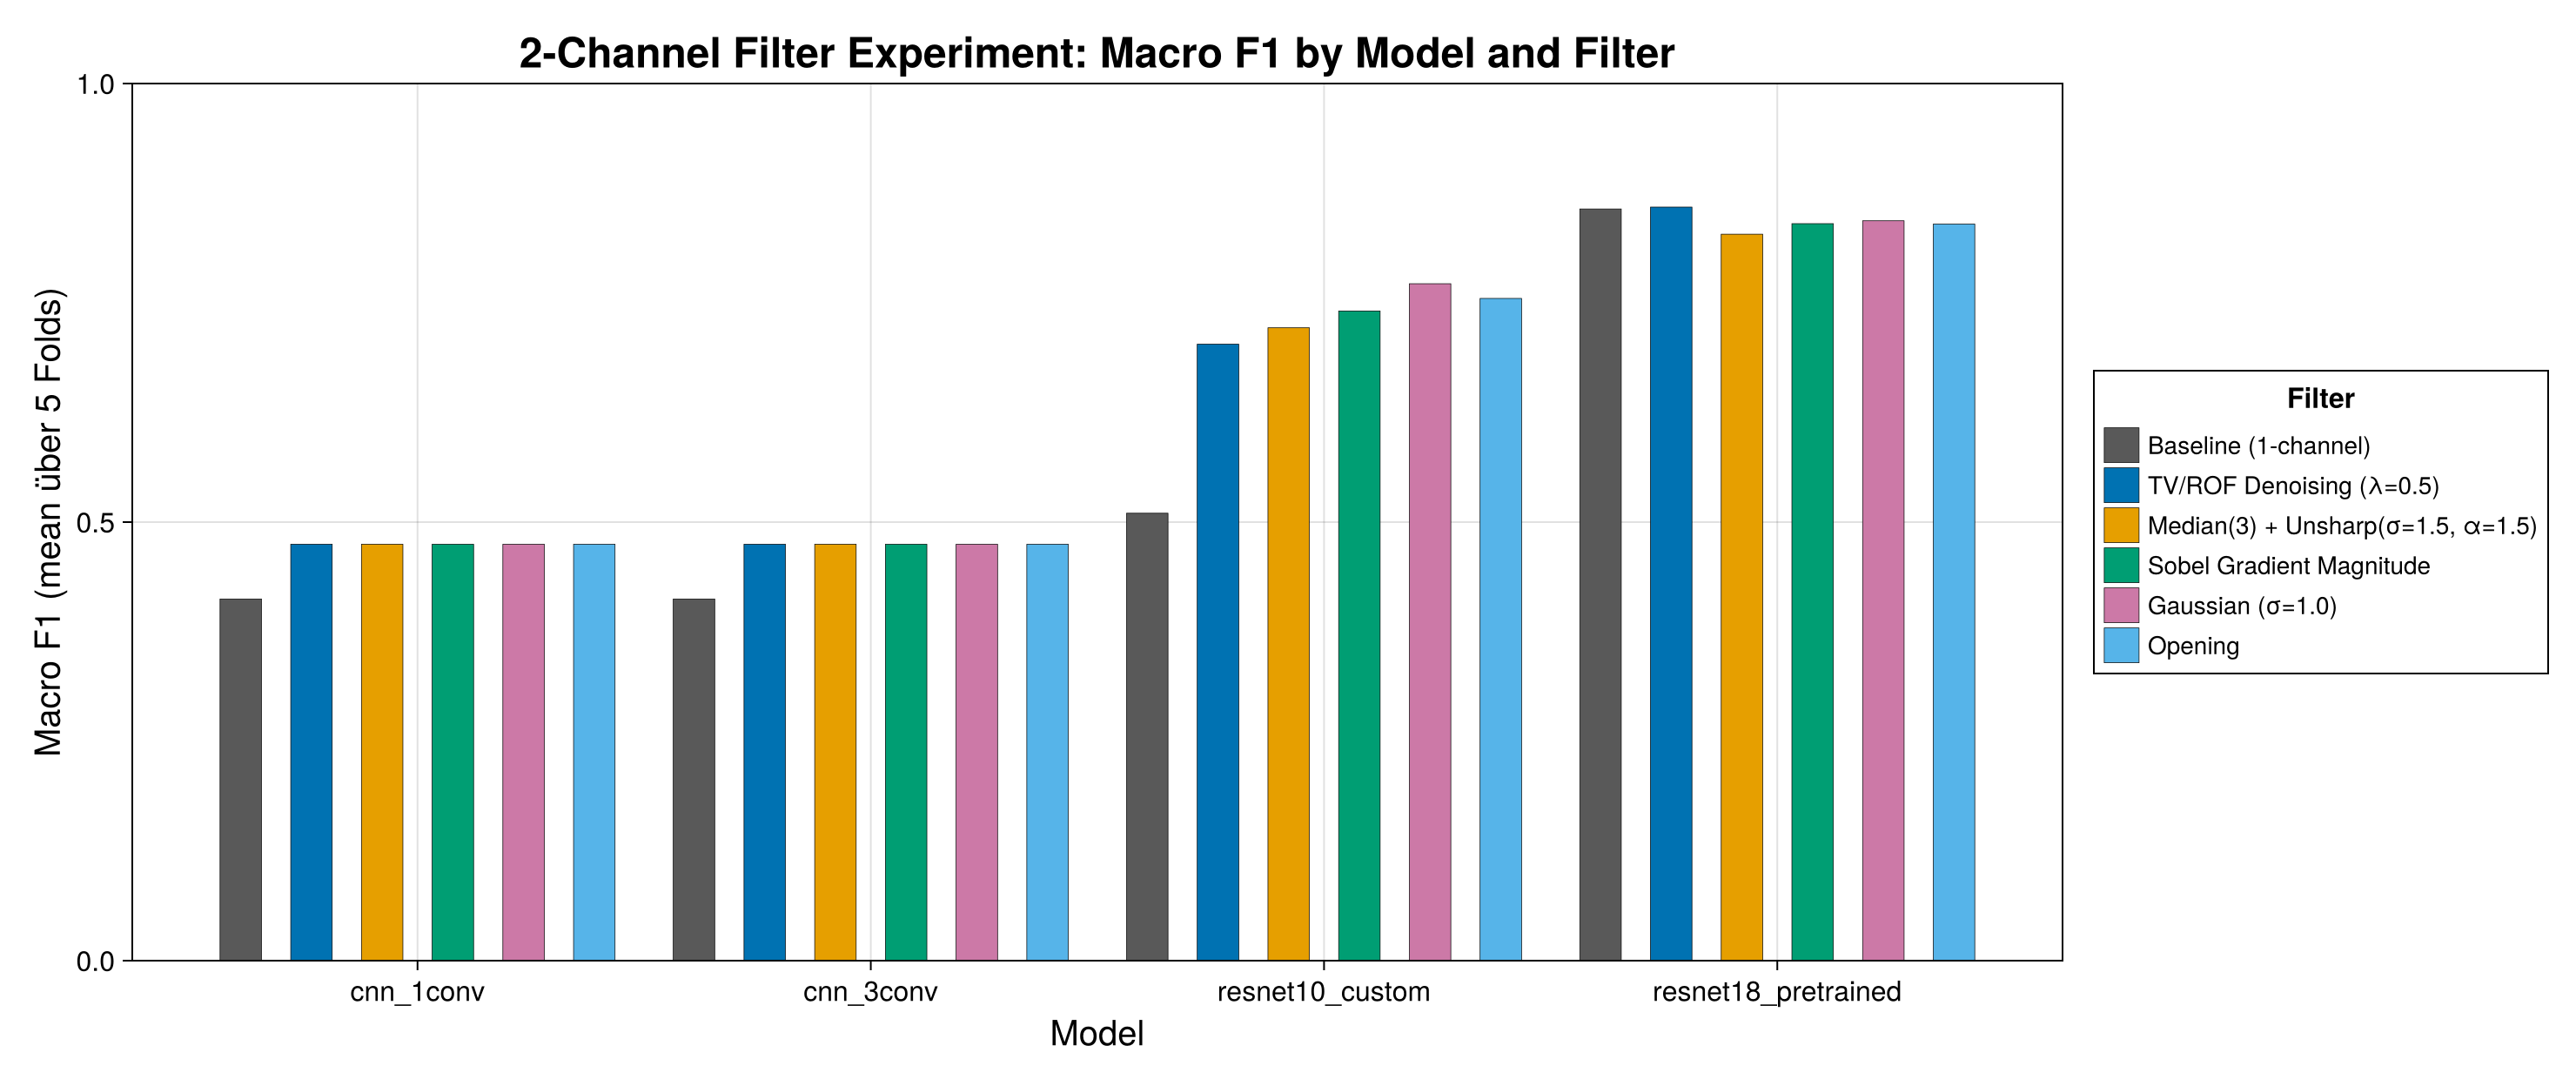

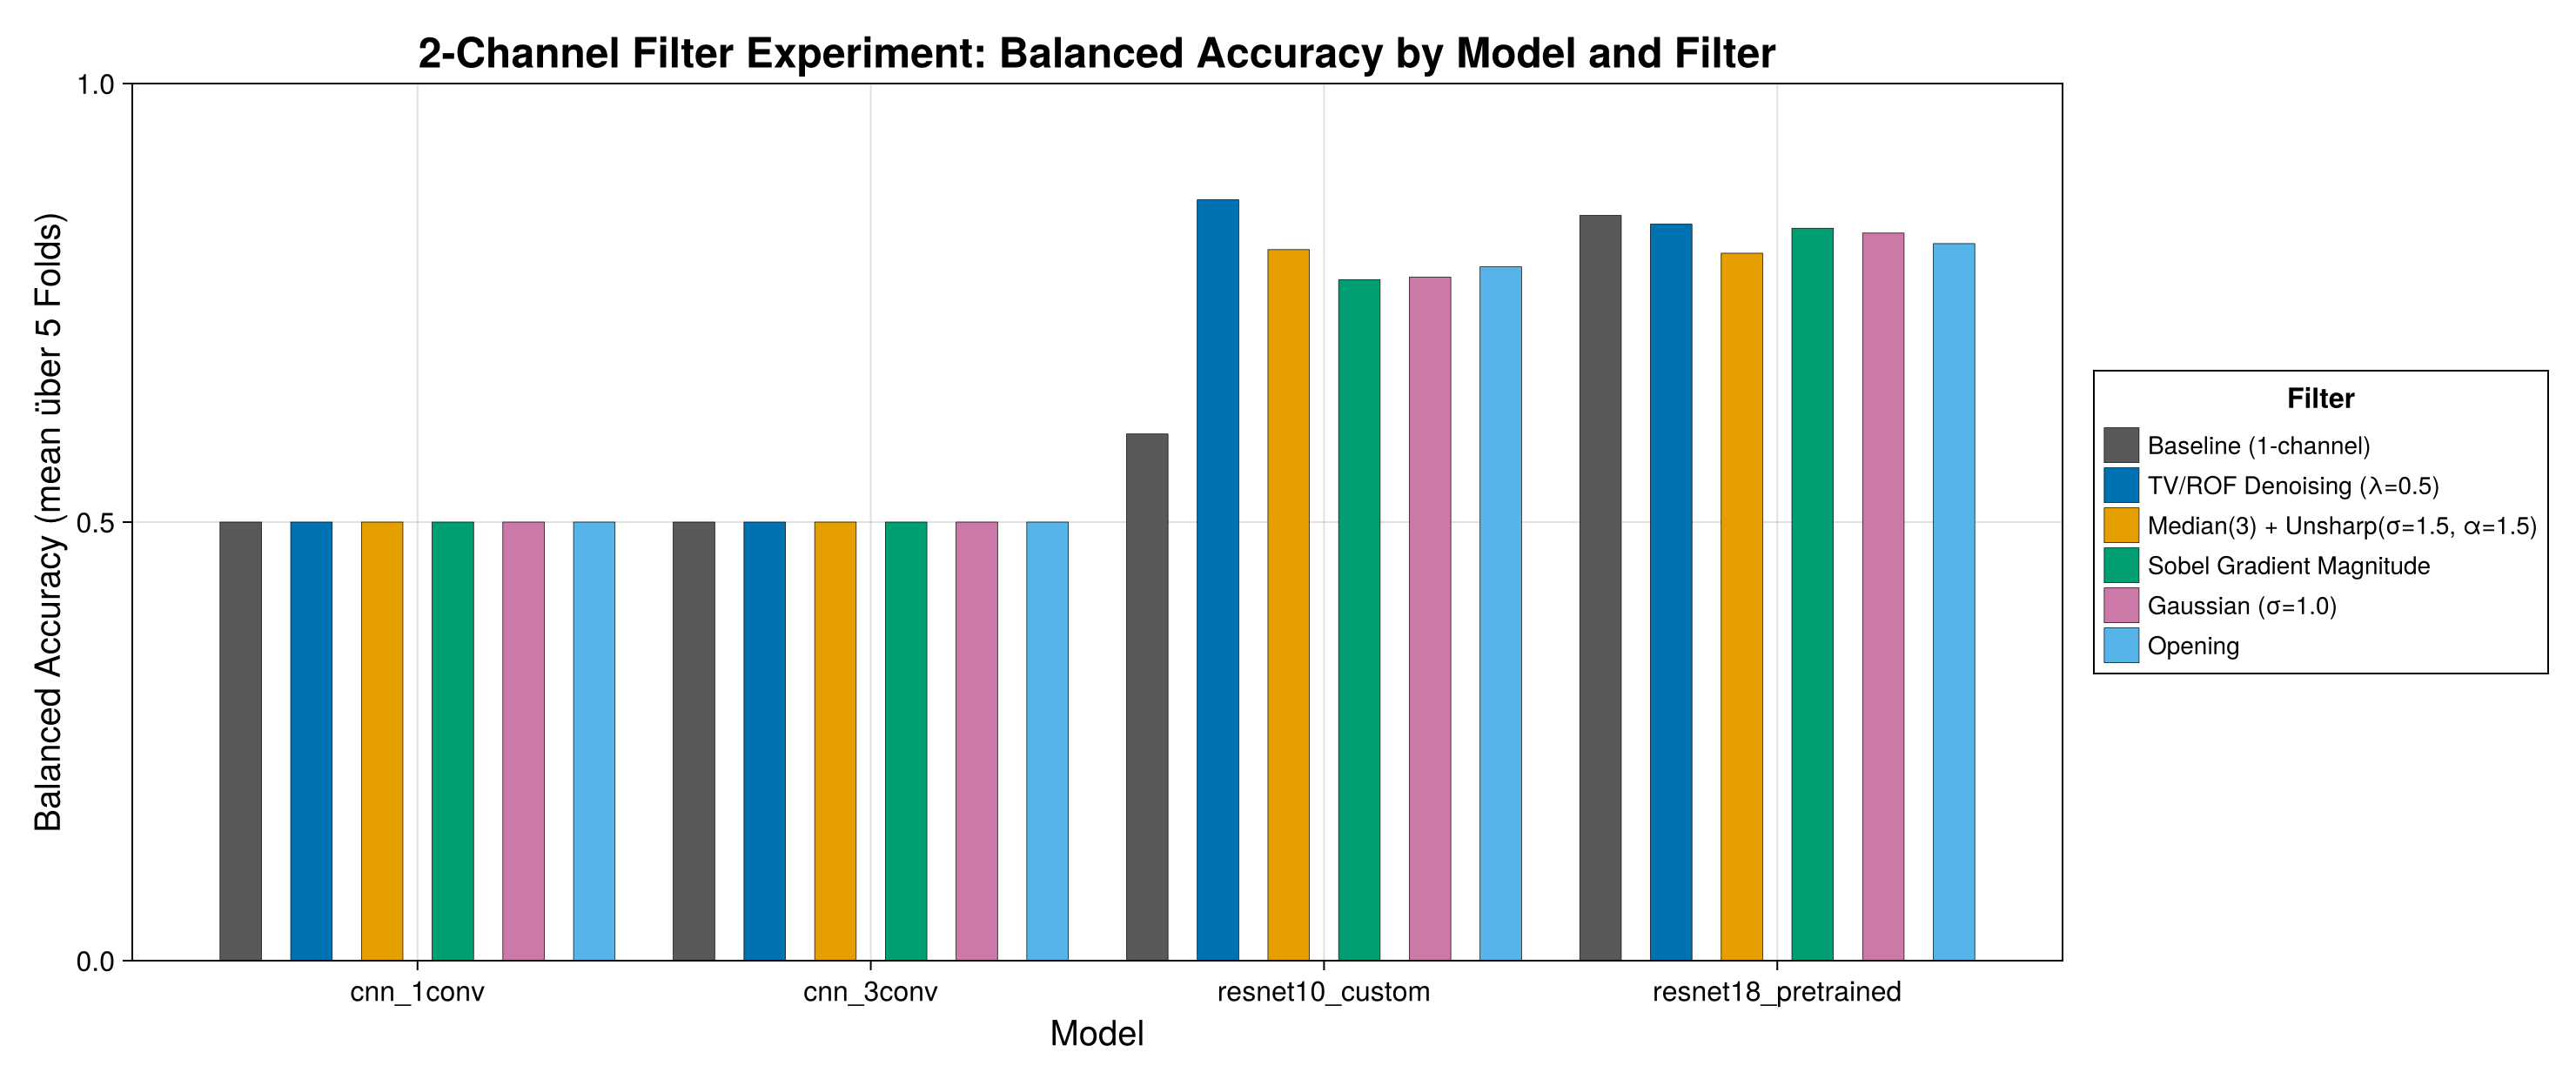

In [29]:
@assert @isdefined(baseline_1ch_df) "Run the 2-channel result tables cell first."
@assert @isdefined(two_channel_summary_df) "Run the 2-channel experiment cell first."

global_top_filters_df = combine(
    groupby(two_channel_summary_df, :filter_name),
    :balanced_accuracy => mean => :mean_balanced_accuracy,
)
sort!(global_top_filters_df, :mean_balanced_accuracy, rev = true)

top5_global_filters = String.(global_top_filters_df.filter_name[1:min(5, nrow(global_top_filters_df))])
plot_group_labels = vcat(["Baseline (1-channel)"], top5_global_filters)

plot_baseline_name_map = Dict(
    "cnn_1conv" => "cnn_1conv",
    "cnn_3conv" => "cnn_3conv",
    "resnet10_custom" => "cnn_10conv",
    "resnet18_pretrained" => "resnet18_pretrained",
)
plot_model_levels = ["cnn_1conv", "cnn_3conv", "resnet10_custom", "resnet18_pretrained"]

function metric_value_for_plot(model_name::String, group_label::String, metric_col::Symbol)
    if group_label == "Baseline (1-channel)"
        baseline_name = plot_baseline_name_map[model_name]
        idx = findfirst(String.(baseline_1ch_df.model_name) .== baseline_name)
        @assert !isnothing(idx) "Missing baseline metric for model $(baseline_name)"
        return Float64(baseline_1ch_df[idx, metric_col])
    end

    idx = findfirst((two_channel_summary_df.filter_name .== group_label) .&
                    (two_channel_summary_df.model_name .== model_name))
    @assert !isnothing(idx) "Missing 2-channel metric for model=$(model_name), filter=$(group_label)"
    return Float64(two_channel_summary_df[idx, metric_col])
end

function plot_two_channel_grouped_bar(metric_col::Symbol, ylabel_text::String, title_text::String)
    fig = Figure(size = (1480, 620))
    ax = Axis(
        fig[1, 1],
        title = title_text,
        xlabel = "Model",
        ylabel = ylabel_text,
        xticks = (collect(1:length(plot_model_levels)), plot_model_levels),
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 16,
        yticklabelsize = 16,
    )

    n_groups = length(plot_group_labels)
    offset_span = 0.78
    offsets = n_groups <= 1 ? [0.0] : collect(range(-offset_span / 2, offset_span / 2, length = n_groups))
    bar_width = n_groups <= 1 ? 0.22 : (offset_span / n_groups) * 0.88

    colors = Makie.wong_colors()
    baseline_color = :gray35
    x = collect(1:length(plot_model_levels))

    for (j, group_label) in enumerate(plot_group_labels)
        y = [metric_value_for_plot(model_name, group_label, metric_col) for model_name in plot_model_levels]
        xj = x .+ offsets[j]

        color_j = group_label == "Baseline (1-channel)" ? baseline_color : colors[((j - 2) % length(colors)) + 1]

        barplot!(
            ax,
            xj,
            y;
            width = bar_width,
            color = color_j,
            strokecolor = :black,
            strokewidth = 0.35,
            label = group_label,
        )
    end

    ylims!(ax, 0, 1)
    Legend(fig[1, 2], ax, "Filter"; labelsize = 14, titlesize = 16)
    return fig
end

println("\nTop-5 Filter (global, nach mean balanced accuracy): ", join(top5_global_filters, ", "))

fig_two_channel_balacc = plot_two_channel_grouped_bar(
    :balanced_accuracy,
    "Balanced Accuracy (mean über 5 Folds)",
    "2-Channel Filter Experiment: Balanced Accuracy by Model and Filter",
)

fig_two_channel_macro_f1 = plot_two_channel_grouped_bar(
    :macro_f1,
    "Macro F1 (mean über 5 Folds)",
    "2-Channel Filter Experiment: Macro F1 by Model and Filter",
)

display(fig_two_channel_macro_f1)
fig_two_channel_balacc
